In [1]:
import json
import re
import os
from pathlib import Path
import pandas as pd

# RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/baseline_results_new/baseline_results"
RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/baseline_results_full_new/baseline_results"

pd.set_option('display.max_colwidth', None)

# Loading predictions

In [2]:
# load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe

# Find all .jsonl files in the result folder
jsonl_files = sorted(list(Path(RESULT_FOLDER_PATH).glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files")

# Load all jsonl files into a list of dataframes
dataframes = {}
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    df = pd.read_json(jsonl_file, lines=True)
    dataframes[jsonl_file.name] = df


Found 20 .jsonl files
Loading predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl
Loading predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl
Loading predictions_gta1_reasoning_direct_query_20251214_220400.jsonl
Loading predictions_gta1_reasoning_relational_query_20251214_220417.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20251213_

In [3]:
gta1_dfs = []
for filename, df in dataframes.items():
    if filename.startswith("predictions_gta1"):
        gta1_dfs.append(df)

# Concatenate all GTA1 DataFrames
if gta1_dfs:
    df_all = pd.concat(gta1_dfs, ignore_index=True)
else:
    raise ValueError("No GTA1 DataFrames found")


# Stitch together re-runs due to the `nan` relational query error at row 1625.
configs = [
    ("predictions_qwen25vl_no_reasoning_direct_query_20251214_022358", "predictions_qwen25vl_no_reasoning_direct_query_20251215_021838", "replace"),
    ("predictions_qwen25vl_no_reasoning_relational_query_20251214_022351", "predictions_qwen25vl_no_reasoning_relational_query_20251215_021833", "concat"),
    ("predictions_qwen25vl_reasoning_direct_query_20251214_022355", "predictions_qwen25vl_reasoning_direct_query_20251215_021836", "replace"),
    ("predictions_qwen25vl_reasoning_relational_query_20251214_022344", "predictions_qwen25vl_reasoning_relational_query_20251215_021829", "concat"),
    ("predictions_uitars15_no_reasoning_direct_query_20251213_223027", "predictions_uitars15_no_reasoning_direct_query_20251215_024416", "replace"),
    ("predictions_uitars15_no_reasoning_relational_query_20251213_222956", "predictions_uitars15_no_reasoning_relational_query_20251215_024414", "replace"),
    ("predictions_uitars15_reasoning_direct_query_20251213_223013", "predictions_uitars15_reasoning_direct_query_20251215_024415", "replace"),
    ("predictions_uitars15_reasoning_relational_query_20251213_222938", "predictions_uitars15_reasoning_relational_query_20251215_024412", "replace")
]

for config in configs:
    big_df = dataframes[config[0]+".jsonl"].copy()
    small_df = dataframes[config[1]+".jsonl"].copy()
    if config[2] == "replace":
        big_df.iloc[-92:] = small_df.values
    elif config[2] == "concat":
        big_df = pd.concat([big_df, small_df], ignore_index=True)

    print(f"config: {config}")
    print(f"len(big_df): {len(big_df)}")
    df_all = pd.concat([df_all, big_df], ignore_index=True)

"""
Processing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)
1716
Processing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)
1716
Processing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)
1716
Processing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)
1716

Processing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)
1716
Processing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)
92

Processing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)
1624
Processing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)
92

Processing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)
1716
Processing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)
92

Processing predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl (11/20)
1624
Processing predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl (12/20)
92

Processing predictions_uitars15_no_reasoning_direct_query_20251213_223027.jsonl (13/20)
1716
Processing predictions_uitars15_no_reasoning_direct_query_20251215_024416.jsonl (14/20)
92

Processing predictions_uitars15_no_reasoning_relational_query_20251213_222956.jsonl (15/20)
1716
Processing predictions_uitars15_no_reasoning_relational_query_20251215_024414.jsonl (16/20)
92

Processing predictions_uitars15_reasoning_direct_query_20251213_223013.jsonl (17/20)
1716
Processing predictions_uitars15_reasoning_direct_query_20251215_024415.jsonl (18/20)
92

Processing predictions_uitars15_reasoning_relational_query_20251213_222938.jsonl (19/20)
1716
Processing predictions_uitars15_reasoning_relational_query_20251215_024412.jsonl (20/20)
92

"""

config: ('predictions_qwen25vl_no_reasoning_direct_query_20251214_022358', 'predictions_qwen25vl_no_reasoning_direct_query_20251215_021838', 'replace')
len(big_df): 1716
config: ('predictions_qwen25vl_no_reasoning_relational_query_20251214_022351', 'predictions_qwen25vl_no_reasoning_relational_query_20251215_021833', 'concat')
len(big_df): 1716
config: ('predictions_qwen25vl_reasoning_direct_query_20251214_022355', 'predictions_qwen25vl_reasoning_direct_query_20251215_021836', 'replace')
len(big_df): 1716
config: ('predictions_qwen25vl_reasoning_relational_query_20251214_022344', 'predictions_qwen25vl_reasoning_relational_query_20251215_021829', 'concat')
len(big_df): 1716
config: ('predictions_uitars15_no_reasoning_direct_query_20251213_223027', 'predictions_uitars15_no_reasoning_direct_query_20251215_024416', 'replace')
len(big_df): 1716
config: ('predictions_uitars15_no_reasoning_relational_query_20251213_222956', 'predictions_uitars15_no_reasoning_relational_query_20251215_024414',

'\nProcessing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)\n1716\nProcessing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)\n1716\nProcessing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)\n1716\nProcessing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)\n1716\n\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)\n1716\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)\n92\n\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)\n1624\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)\n1716\nProcessing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_relational_query_2025121

In [4]:
# # load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe

# # Find all .jsonl files in the result folder
# jsonl_files = list(Path(RESULT_FOLDER_PATH).glob("*.jsonl"))
# print(f"Found {len(jsonl_files)} .jsonl files")

# # Load all jsonl files into a list of dataframes
# dataframes = []
# for jsonl_file in jsonl_files:
#     print(f"Loading {jsonl_file.name}")
#     df = pd.read_json(jsonl_file, lines=True)
#     dataframes.append(df)

# # Concatenate all dataframes into one
# df_all = pd.concat(dataframes, ignore_index=True)

print(f"\nTotal rows loaded: {len(df_all)}")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nFirst few rows:")
df_all.head()
df_all.info()
df_all.isna().sum()
pd.set_option('display.max_rows', None)
# df_all.groupby(["model", "use_reasoning", "query_type"]).value_counts()



Total rows loaded: 20592

Columns: ['model', 'use_reasoning', 'query_type', 'test_split', 'variant', 'task_id', 'step_index', 'instruction', 'raw_prediction', 'ground_truth_bbox', 'image_path', 'step_time_seconds']

First few rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              20592 non-null  object 
 1   use_reasoning      20592 non-null  bool   
 2   query_type         20592 non-null  object 
 3   test_split         20592 non-null  object 
 4   variant            20592 non-null  object 
 5   task_id            20592 non-null  object 
 6   step_index         20592 non-null  int64  
 7   instruction        20592 non-null  object 
 8   raw_prediction     20592 non-null  object 
 9   ground_truth_bbox  20592 non-null  object 
 10  image_path         20592 non-null  object 
 11  step_time_seconds  20592 non-

In [5]:
# pd.concat([gta1_df, qwen_df, uitars15_df]).to_csv('baseline_results_combined.csv', index=False)
df_all.to_csv('baseline_results_full_new.csv', index=False)


# Parse raw predictions into actions for each model

## Common helper code

In [6]:
import math

IMAGE_FACTOR = 28
MIN_PIXELS = 100 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28
MAX_RATIO = 200
IMAGE_HEIGHT = 1080
IMAGE_WIDTH = 1920

def escape_single_quotes(text):
    # 匹配未转义的单引号（不匹配 \\'）
    pattern = r"(?<!\\)'"
    return re.sub(pattern, r"\\'", text)

def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor


def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor


def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor    


def smart_resize(
    height: int, width: int, factor: int = IMAGE_FACTOR, min_pixels: int = MIN_PIXELS, max_pixels: int = MAX_PIXELS
) -> tuple[int, int]:
    """
    Rescales the image so that the following conditions are met:

    1. Both dimensions (height and width) are divisible by 'factor'.

    2. The total number of pixels is within the range ['min_pixels', 'max_pixels'].

    3. The aspect ratio of the image is maintained as closely as possible.
    """
    if max(height, width) / min(height, width) > MAX_RATIO:
        raise ValueError(
            f"absolute aspect ratio must be smaller than {MAX_RATIO}, got {max(height, width) / min(height, width)}"
        )
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = floor_by_factor(height / beta, factor)
        w_bar = floor_by_factor(width / beta, factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = ceil_by_factor(height * beta, factor)
        w_bar = ceil_by_factor(width * beta, factor)
    return h_bar, w_bar


## Qwen2.5VL

Need to parse for number of <tool_call> </tool_tool>, each is an action. And then parse for arguments in
```
<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}
</tool_call>
```
----
```
Thought: I need to locate the textbox labeled 'To Los Angeles (LAX)' and replace 'Los Angeles (LAX)' with 'SAN FRANCISCO'. The textbox is clearly visible and identifiable.
<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [704, 468]}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "type", "text": "SAN FRANCISCO"}}
</tool_call>

 addCriterion
```

- for rows with multiple actions, parse the coordinates from the first action with coordinates as the coordinates
- for rows with multiple actions, parse the first non-click action as the action type. for example, click, type, finished(), should have type as its action type for the row. Another example, call_user() should have 'call_user' as the action type
- browser_select_option get converted to 'select' action




In [7]:

def parse_qwen_action(response):
    # Calculate the real image size sent into the model
    resized_height, resized_width = smart_resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        factor=IMAGE_FACTOR,
        min_pixels=MIN_PIXELS,
        max_pixels=MAX_PIXELS,
    )
    
    result_dict = {
        "result": "positive",
        "format": "x1y1x2y2",
        "raw_response": response,
        "bbox": None,
        "point": None,
        "coordinates": None,
        "action_type": None
    }

    # Check if response already has tool_call tags
    if '<tool_call>' not in response:
        # Fallback to old logic: add guide_text
        guide_text = "<tool_call>\n{\"name\": \"computer_use\", \"arguments\": {\"action\": \"left_click\", \"coordinate\": ["
        response = guide_text + response
        cut_index = response.rfind('}')
        if cut_index != -1:
            response = response[:cut_index + 1]
    
    # Find all <tool_call>...</tool_call> blocks
    tool_call_pattern = r'<tool_call>\s*(.*?)\s*</tool_call>'
    tool_calls = re.findall(tool_call_pattern, response, re.DOTALL)
    
    if not tool_calls:
        return result_dict
    
    # Parse all actions
    actions = []
    # Valid click actions from the prompt enum
    click_actions = {'left_click', 'right_click', 'middle_click', 'double_click', 'left_click_drag'}
    # All valid actions from the prompt enum
    valid_actions = {'key', 'type', 'mouse_move', 'left_click', 'left_click_drag', 
                     'right_click', 'middle_click', 'double_click', 'scroll', 'wait', 'terminate'}
    
    for tool_call_str in tool_calls:
        try:
            action = json.loads(tool_call_str.strip())
            if 'arguments' in action:
                actions.append(action)
        except (json.JSONDecodeError, ValueError, TypeError):
            continue
    
    if not actions:
        return result_dict
    
    # Extract coordinates from the first action that has coordinates
    # Note: coordinate is required for mouse_move and left_click_drag, but may also appear with left_click
    for action in actions:
        if 'arguments' in action and isinstance(action['arguments'], dict):
            if 'coordinate' in action['arguments']:
                coordinates = action['arguments']['coordinate']
                if isinstance(coordinates, list) and len(coordinates) >= 2:
                    if len(coordinates) == 2:
                        point_x, point_y = float(coordinates[0]), float(coordinates[1])
                    elif len(coordinates) == 4:
                        x1, y1, x2, y2 = float(coordinates[0]), float(coordinates[1]), float(coordinates[2]), float(coordinates[3])
                        point_x = (x1 + x2) / 2
                        point_y = (y1 + y2) / 2
                    else:
                        continue
                    # Normalize and denormalize predicted coordinates into image dimensions
                    result_dict["point"] = [point_x / resized_width * IMAGE_WIDTH, point_y / resized_height * IMAGE_HEIGHT]
                    result_dict["coordinates"] = [point_x / resized_width * IMAGE_WIDTH, point_y / resized_height * IMAGE_HEIGHT]
                    break
    
    # Extract action type: first non-click action, or first action if all are clicks
    for action in actions:
        if 'arguments' in action and isinstance(action['arguments'], dict):
            if 'action' in action['arguments']:
                action_name = action['arguments']['action']
                # Validate it's a valid action
                if action_name in valid_actions:
                    # If it's not a click action, use it
                    if action_name not in click_actions:
                        result_dict["action_type"] = action_name
                        return result_dict
    
    # If all actions were clicks (or no valid action found), use the first action's type
    if actions:
        first_action = actions[0]
        if 'arguments' in first_action and isinstance(first_action['arguments'], dict):
            if 'action' in first_action['arguments']:
                action_name = first_action['arguments']['action']
                if action_name in valid_actions:
                    result_dict["action_type"] = action_name
    
    return result_dict


In [8]:
import re
import json
from typing import Tuple, Optional, List

def parse_qwen_prediction(raw_prediction: str, debug: bool = True) -> Tuple[Optional[str], Optional[List[int]]]:
    """
    Parse action type and coordinates from Qwen2.5VL raw predictions.
    
    Args:
        raw_prediction: Raw text prediction from Qwen2.5VL model
        debug: If True, print debug information
        
    Returns:
        Tuple of (action_type, coordinates) where:
        - action_type: str or None (e.g., 'type', 'call_user', 'left_click', etc.)
        - coordinates: [x, y] list or None
        
    Special handling:
    - For multiple actions: extracts coordinates from first action with coordinates
    - For multiple actions: returns first non-click action type (e.g., 'type', 'call_user')
    - If only click actions exist, returns the first click action type
    - Returns (None, None) for predictions without valid tool calls
    """
    
    # First try to extract from <tool_call> tags
    # Handle both actual newlines and escaped \n characters
    tool_call_pattern = r'<tool_call>[\s\\n]*(\{.*?\})[\s\\n]*</tool_call>'
    tool_calls = re.findall(tool_call_pattern, raw_prediction, re.DOTALL)
    
    # if debug and tool_calls:
    #     print(f"  Found {len(tool_calls)} tool_call(s)")
    #     for idx, tc in enumerate(tool_calls):
    #         print(f"    Tool call {idx + 1}: {tc[:100]}...")
    
    # If no <tool_call> tags found, try to find JSON in markdown code blocks
    if not tool_calls:
        # Look for ```json blocks or standalone JSON objects
        code_block_pattern = r'```(?:json)?[\s\\n]*(\{.*?\})[\s\\n]*```'
        code_blocks = re.findall(code_block_pattern, raw_prediction, re.DOTALL)
        
        if code_blocks:
            tool_calls = code_blocks
            if debug:
                print(f"  Found {len(code_blocks)} code block(s)")
        else:
            # Try to find standalone JSON objects (as a last resort)
            # Only if the text looks like it might contain a tool call
            if '"computer_use"' in raw_prediction and '"arguments"' in raw_prediction:
                json_pattern = r'\{[^{}]*"name"\s*:\s*"computer_use"[^{}]*"arguments"\s*:\s*\{[^}]*\}[^}]*\}'
                standalone_json = re.findall(json_pattern, raw_prediction, re.DOTALL)
                if standalone_json:
                    tool_calls = standalone_json
                    if debug:
                        print(f"  Found {len(standalone_json)} standalone JSON(s)")
    
    if not tool_calls:
        # No valid tool calls found - this is a refusal/explanation
        if debug:
            print("  No tool calls found - returning (None, None)")
        return None, None
    
    # Parse all actions
    actions = []
    for tool_call_str in tool_calls:
        try:
            # Clean up the JSON string - remove escaped newlines and extra whitespace
            tool_call_str = tool_call_str.strip()
            tool_call_str = tool_call_str.replace('\\n', '')
            tool_call_json = json.loads(tool_call_str)
            
            # Handle both direct arguments and nested structure
            if 'arguments' in tool_call_json:
                actions.append(tool_call_json['arguments'])
            elif 'action' in tool_call_json:
                # Direct action format (less common)
                actions.append(tool_call_json)
        except json.JSONDecodeError as e:
            if debug:
                print(f"  JSON decode error: {e}")
            # Skip malformed JSON
            continue
    
    if not actions:
        if debug:
            print("  No valid actions parsed - returning (None, None)")
        return None, None
    
    if debug and len(actions) > 1:
        print(f"  *** MULTIPLE ACTIONS DETECTED: {len(actions)} actions ***")
        for idx, action in enumerate(actions):
            print(f"    Action {idx + 1}: {action}")
    
    # Extract coordinates from first action that has them
    coordinates = None
    for action in actions:
        if 'coordinate' in action and action['coordinate']:
            coordinates = action['coordinate']
            # if debug:
            #     print(f"  Coordinates from action: {coordinates}")
            break
    
    # Determine action type: first non-click action, or first action if all are clicks
    click_actions = {'left_click', 'right_click', 'middle_click', 'double_click', 
                     'mouse_move', 'left_click_drag'}
    
    action_type = None
    non_click_action = None
    
    for action in actions:
        action_name = action.get('action', '')
        
        # Store first action as fallback
        if action_type is None:
            action_type = 'click'
        
        # Look for first non-click action
        if action_name not in click_actions:
            non_click_action = action_name
            if debug and len(actions) > 1:
                print(f"  Found non-click action: {non_click_action}")
            break
    
    # Use non-click action if found, otherwise use first action
    if non_click_action:
        action_type = non_click_action
    
    if debug and len(actions) > 1:
        print(f"-"*100+"\n")
        print(f"  Raw prediction: {raw_prediction}")
        print(f"-"*100+"\n")
        print(f"  Final action_type selected: {action_type}")
        print(f"  Final coordinates selected: {coordinates}\n")
        print(f"="*100+"\n")
    
    # Handle special cases like 'terminate' with status
    if action_type == 'terminate' and actions:
        for action in actions:
            if action.get('action') == 'terminate' and 'status' in action:
                status = action.get('status', '')
                if status:
                    action_type = f"terminate_{status}"
                break

    if action_type == 'browser_select_option':
        action_type = 'select'

    return action_type, coordinates


# Test with problematic examples
if __name__ == "__main__":
    examples = [
        # Example 1: Type action with escaped newlines (literal \n)
        r'Thought: The goal is to type \'nutritionist\' into the search box labeled \'What\'. The current input is \'nutritionist\', which matches the intended search term.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "type", "text": "nutritionist"}}\n</tool_call>',
        
        # Example 2: Scroll action with escaped newlines (literal \n)
        r'Thought: The goal is to click on the link above \'APPLY\'. Since there isn\'t a visible \'APPLY\' button in the current view, I\'ll need to scroll down to find it.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "scroll", "pixels": -400}}\n</tool_call>',
        
        # Example 3: JSON in code block
        '```json\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [510, 622]}}\n```',
        
        # Example 4: Simple tool call with real newlines
        '<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}\n</tool_call>',
        
        # Example 5: Multiple actions with real newlines
        'Thought: I need to locate the textbox.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [704, 468]}}\n</tool_call>\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "type", "text": "SAN FRANCISCO"}}\n</tool_call>',
    ]
    
    for i, example in enumerate(examples, 1):
        print(f"\n{'='*60}")
        print(f"Example {i}:")
        print(f"  Raw (first 150 chars): {repr(example[:150])}")
        action_type, coords = parse_qwen_prediction(example, debug=True)
        print(f"\n  RESULT:")
        print(f"    Action type: {action_type}")
        print(f"    Coordinates: {coords}")
        print(f"    Valid action: {action_type is not None}")


Example 1:
  Raw (first 150 chars): "Thought: The goal is to type \\'nutritionist\\' into the search box labeled \\'What\\'. The current input is \\'nutritionist\\', which matches the intended "

  RESULT:
    Action type: type
    Coordinates: None
    Valid action: True

Example 2:
  Raw (first 150 chars): "Thought: The goal is to click on the link above \\'APPLY\\'. Since there isn\\'t a visible \\'APPLY\\' button in the current view, I\\'ll need to scroll dow"

  RESULT:
    Action type: scroll
    Coordinates: None
    Valid action: True

Example 3:
  Raw (first 150 chars): '```json\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [510, 622]}}\n```'
  Found 1 code block(s)

  RESULT:
    Action type: click
    Coordinates: [510, 622]
    Valid action: True

Example 4:
  Raw (first 150 chars): '<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}\n</tool_call>'

  RESULT:
    Action type: click
    Coor

In [9]:
qwen_filter = df_all['model'] == 'qwen25vl'
qwen_df = df_all[qwen_filter].copy()
results = qwen_df['raw_prediction'].apply(parse_qwen_prediction)
qwen_df['action_type'] = results.apply(lambda x: x[0])
qwen_df['coordinates'] = results.apply(lambda x: x[1])
# qwen_df[['coordinates', 'action_type']].head()
print(qwen_df['coordinates'].isna().sum())
# qwen_df[qwen_df['coordinates'].isna()].head(20)
qwen_df.info()
qwen_df.groupby('action_type')[['model', 'use_reasoning', 'query_type', 'action_type']].value_counts()



  *** MULTIPLE ACTIONS DETECTED: 3 actions ***
    Action 1: {'action': 'left_click', 'coordinate': [1270, 544]}
    Action 2: {'action': 'type', 'text': 'BCD Studio'}
    Action 3: {'action': 'key', 'keys': ['enter']}
  Found non-click action: type
----------------------------------------------------------------------------------------------------

  Raw prediction: <tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [1270, 544]}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "type", "text": "BCD Studio"}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "key", "keys": ["enter"]}}
</tool_call>
----------------------------------------------------------------------------------------------------

  Final action_type selected: type
  Final coordinates selected: [1270, 544]


  *** MULTIPLE ACTIONS DETECTED: 3 actions ***
    Action 1: {'action': 'left_click', 'coordinate': [1245, 546]}
    Action 2: 

action_type  model     use_reasoning  query_type      
click        qwen25vl  True           relational_query    1643
                                      direct_query        1618
                       False          relational_query    1546
                                      direct_query        1514
scroll       qwen25vl  True           relational_query       1
select       qwen25vl  False          relational_query       4
                       True           direct_query           1
                                      relational_query       1
type         qwen25vl  False          direct_query         202
                                      relational_query     152
                       True           direct_query          97
                                      relational_query      71
Name: count, dtype: int64

## UI-TARS1.5

Parse for:
1. `Action: click(start_box='(681,385)')`
2. `Action: click(start_box='(1168,198]')`


In [10]:
import ast

# UI-TARS1.5 action parsing functions
def parse_action(action_str):
    try:
        # 解析字符串为 AST 节点
        node = ast.parse(action_str, mode='eval')

        # 确保节点是一个表达式
        if not isinstance(node, ast.Expression):
            raise ValueError("Not an expression")

        # 获取表达式的主体
        call = node.body

        # 确保主体是一个函数调用
        if not isinstance(call, ast.Call):
            raise ValueError("Not a function call")

        # 获取函数名
        if isinstance(call.func, ast.Name):
            func_name = call.func.id
        elif isinstance(call.func, ast.Attribute):
            func_name = call.func.attr
        else:
            func_name = None

        # 获取关键字参数
        kwargs = {}
        for kw in call.keywords:
            key = kw.arg
            # 处理不同类型的值，这里假设都是常量
            if isinstance(kw.value, ast.Constant):
                value = kw.value.value
            elif isinstance(kw.value, ast.Str):  # 兼容旧版本 Python
                value = kw.value.s
            else:
                value = None
            kwargs[key] = value

        return {
            'function': func_name,
            'args': kwargs
        }

    except Exception as e:
        print(f"Failed to parse action '{action_str}': {e}")
        return None

def parse_action_to_structure_output(text, factor = IMAGE_FACTOR, origin_resized_height = 1080, origin_resized_width = 1920, model_type = "qwen25vl", max_pixels=16384*28*28, min_pixels=100*28*28):
    text = text.strip()
    if model_type == "qwen25vl":
        smart_resize_height, smart_resize_width = smart_resize(origin_resized_height, origin_resized_width, factor=IMAGE_FACTOR, min_pixels=min_pixels, max_pixels=max_pixels)

    # 正则表达式匹配 Action 字符串
    if text.startswith("Thought:"):
        thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
        thought_hint = "Thought: "
    elif text.startswith("Reflection:"):
        thought_pattern = r"Reflection: (.+?)Action_Summary: (.+?)(?=\s*Action:|$)"
        thought_hint = "Reflection: "
    elif text.startswith("Action_Summary:"):
        thought_pattern = r"Action_Summary: (.+?)(?=\s*Action:|$)"
        thought_hint = "Action_Summary: "
    else:
        thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
        thought_hint = "Thought: "
    reflection, thought = None, None
    thought_match = re.search(thought_pattern, text, re.DOTALL)
    if thought_match:
        if len(thought_match.groups()) == 1:
            thought = thought_match.group(1).strip()
        elif len(thought_match.groups()) == 2:
            thought = thought_match.group(2).strip()
            reflection = thought_match.group(1).strip()
    assert "Action:" in text
    action_str = text.split("Action:")[-1]

    tmp_all_action = action_str.split("\n\n")
    all_action = []
    for action_str in tmp_all_action:
        if "type(content" in action_str:
            # 正则表达式匹配 content 中的字符串并转义单引号
            def escape_quotes(match):
                content = match.group(1)  # 获取 content 的值
                return content

            # 使用正则表达式进行替换
            pattern = r"type\(content='(.*?)'\)"  # 匹配 type(content='...')
            content = re.sub(pattern, escape_quotes, action_str)

            # 处理字符串
            action_str = escape_single_quotes(content)
            action_str = "type(content='" + action_str + "')"
        all_action.append(action_str)

    parsed_actions = [parse_action(action.replace("\n","\\n").lstrip()) for action in all_action]
    actions = []
    for action_instance, raw_str in zip(parsed_actions, all_action):
        if action_instance == None:
            print(f"Action can't parse: {raw_str}")
            raise ValueError(f"Action can't parse: {raw_str}") 
        action_type = action_instance["function"]
        params = action_instance["args"]

        # import pdb; pdb.set_trace()
        action_inputs = {}
        for param_name, param in params.items():
            if param == "": continue
            param = param.lstrip()  # 去掉引号和多余的空格
            # 处理start_box或者end_box参数格式 '<bbox>x1 y1 x2 y2</bbox>'
            action_inputs[param_name.strip()] = param
            
            if "start_box" in param_name or "end_box" in param_name:
                ori_box = param
                # Remove parentheses and brackets, then split the string by commas
                numbers = ori_box.replace("(", "").replace(")", "").replace("[", "").replace("]", "").split(",")
                # Convert to float and scale by 1000
                # Qwen2.5vl output absolute coordinates, qwen2vl output relative coordinates
                if model_type == "qwen25vl":
                    float_numbers = []
                    for num_idx, num in enumerate(numbers):
                        num = float(num)
                        if (num_idx + 1) % 2 == 0:
                            float_numbers.append(round(float(num/smart_resize_height * IMAGE_HEIGHT)))
                        else:
                            float_numbers.append(round(float(num/smart_resize_width * IMAGE_WIDTH)))
                else:
                    raise ValueError(f"Unknown model type: {model_type}")

                # if len(float_numbers) == 2:
                #     float_numbers = [float_numbers[0], float_numbers[1], float_numbers[0], float_numbers[1]]
                action_inputs[param_name.strip()] = str(float_numbers)

        # import pdb; pdb.set_trace()
        actions.append({
            "reflection": reflection,
            "thought": thought,
            "action_type": action_type,
            "action_inputs": action_inputs,
            "text": text
        })
    return actions




In [11]:
uitars15_filter = df_all['model'] == 'uitars15'
uitars15_df = df_all[uitars15_filter].copy()

uitars15_df['structured_actions'] = uitars15_df['raw_prediction'].apply(parse_action_to_structure_output)  # use qwen25vl for uitars15
pd.set_option('display.max_columns', None)

# def has_more_than_1_action(row):
#     return True if len(row['structured_actions']) > 1 else False

# print("rows with more than 1 action:")
# display(len(uitars15_df[uitars15_df.apply(has_more_than_1_action, axis=1)]))


# def has_non_click_action(row):
#     return True if any(action['action_type'] != 'click' for action in row['structured_actions']) else False

# display(uitars15_df[uitars15_df.apply(has_non_click_action, axis=1)][['raw_prediction', 'structured_actions']].head())

def get_action_type_and_coordinates_from_structured_actions_for_uitars15(row):
    structured_actions = row['structured_actions']
    action_type = structured_actions[0]['action_type']
    if action_type == 'click':
        coordinates = structured_actions[0]['action_inputs']['start_box']
        coordinates = ast.literal_eval(coordinates)
        return action_type, coordinates

    else:
        # from pprint import pprint
        # pprint(structured_actions)
        coordinates = None
    return action_type, coordinates

uitars15_df['action_type'], uitars15_df['coordinates'] = zip(*uitars15_df.apply(get_action_type_and_coordinates_from_structured_actions_for_uitars15, axis=1))
uitars15_df.groupby('action_type')[['model', 'use_reasoning', 'query_type', 'action_type']].value_counts()
uitars15_df[uitars15_df['action_type'] == 'click'].head()

,model,use_reasoning,query_type,test_split,variant,task_id,step_index,instruction,raw_prediction,ground_truth_bbox,image_path,step_time_seconds,structured_actions,action_type,coordinates
13728,uitars15,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(683,324)')","[657, 300, 44, 42]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.063,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[679, 320]'}, 'text': 'Action: click(start_box='(683,324)')'}]",click,"[679, 320]"
13729,uitars15,False,direct_query,test_task_style,precision,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(768,226)')","[747.8953247070312, 210, 30.79998779296875, 29.399993896484375]",/mnt/test_splits/run_20251112_005206_test_task_precision/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.700,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[763, 224]'}, 'text': 'Action: click(start_box='(768,226)')'}]",click,"[763, 224]"
13730,uitars15,False,direct_query,test_task_style,style,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(256,388)')","[657, 320.71875, 44, 42]",/mnt/test_splits/run_20251112_005316_test_task_style/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.534,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[254, 384]'}, 'text': 'Action: click(start_box='(256,388)')'}]",click,"[254, 384]"
13731,uitars15,False,direct_query,test_task_style,text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(676,325)')","[649.5, 300, 44, 42]",/mnt/test_splits/run_20251113_005227_test_task_text_shrink/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.733,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[672, 321]'}, 'text': 'Action: click(start_box='(676,325)')'}]",click,"[672, 321]"
13732,uitars15,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,5,Click on 'Cooking' button,"Action: click(start_box='(1099,548)')","[1065.03125, 531.5, 53.28125, 17]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_5_click.png,2.553,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[1092, 542]'}, 'text': 'Action: click(start_box='(1099,548)')'}]",click,"[1092, 542]"


## GTA1

Parse for:
1. `Action: click(start_box='(648,409)')`
2. 
    ```
    Thought: I noticed a search box at the top of the page, which is perfect for looking up pork. I need to click on it first to make it active so that I can enter the keyword.
    Action: (583,287)
    ```
3. `(1444,42)`
4. `-203,240`
5. 
    ```
    Thought: I noticed the link for Audiology, which is located just below the Allergies & Immunology link. It's positioned in the left column, and I need to click on it to access the relevant page.
    Action: (389,546)
    assistant
    Thought: I'm currently looking at the list of medical specialties, and I've found the link for Anesthesiology. It's located in the left column, just below the Allergy & Immunology link. I need to click on it to learn more about this field.
    Action: (408,503)
    assistant
    Thought: I'm currently browsing through the list of medical specialties and I've come across the link for Audiology. It's positioned in the left column, just below the Allergy & Immunology link. I need to click on it to get more information about this field.
    Action: (389,546)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    ...
    ```

In [12]:
def extract_coordinates(raw_string):
    try:
        # First try to match coordinates with parentheses: (x,y) or (x, y)
        matches = re.findall(r"\((-?\d*\.?\d+),\s*(-?\d*\.?\d+)\)", raw_string)
        if matches:
            return [int(matches[0][0]), int(matches[0][1])]
        
        # If no parentheses match, try without parentheses: x,y or -x,y
        matches = re.findall(r"(-?\d+\.?\d*),\s*(-?\d+\.?\d*)", raw_string)
        if matches:
            return tuple(map(int, matches[0]))
        
        return [0, 0]
    except:
        return [0, 0]


In [13]:
gta1_filter = df_all['model'] == 'gta1'
gta1_df = df_all[gta1_filter].copy()
gta1_df['coordinates'] = gta1_df['raw_prediction'].apply(extract_coordinates)
smart_resize_height, smart_resize_width = smart_resize(IMAGE_HEIGHT, IMAGE_WIDTH, factor=IMAGE_FACTOR, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
print(smart_resize_height, smart_resize_width)
gta1_df['coordinates'] = gta1_df['coordinates'].apply(lambda x: [x[0] / smart_resize_height * IMAGE_HEIGHT, x[1] / smart_resize_width * IMAGE_WIDTH])

1092 1932


# Check for anomalies (na, malformed, etc)

In [14]:
uitars15_df.isna().sum()

model                  0
use_reasoning          0
query_type             0
test_split             0
variant                0
task_id                0
step_index             0
instruction            0
raw_prediction         0
ground_truth_bbox      0
image_path             0
step_time_seconds      0
structured_actions     0
action_type            0
coordinates           22
dtype: int64

# Denormalize all coordinates

UITARS and Qwen should have denormalization logic in their parsing logic, but double check. GTA1 would need denormalization

# Calculate action str exact match

Since GTA1 was trained to output coordinates only, it's not very meaningful to compare action str exact match.

In [15]:
def is_action_type_correct(row):
    gt_action_type = row['instruction'].strip().split(' ')[0].lower()
    if gt_action_type not in ['click', 'type', 'select', 'scroll']:
        print(f"Action type not in ['click', 'type', 'select', 'scroll']: {gt_action_type}")
        return 0
    if row['action_type'] == gt_action_type:
        return 1
    elif row['action_type'] in ['type', 'click'] and gt_action_type == 'select':
        return 1
    else:
        # print(f"Action type mismatch: {action_type} != {gt_action_type}")
        return 0

# qwen_df[(qwen_df['action_exact_match'] == 0)].head()
display(qwen_df.apply(is_action_type_correct, axis=1).sum() / qwen_df.shape[0])

# uitars15_df[(uitars15_df['action_exact_match'] == 0)].head()
display(uitars15_df.apply(is_action_type_correct, axis=1).sum() / uitars15_df.shape[0])



np.float64(0.965034965034965)

np.float64(0.8948135198135199)

# Calculate hit box accuracy

In [16]:
import ast

def is_coords_in_bbox(coords, bbox):
    if coords is None:
        return 0

    tolerance = 20
    x1, y1, w, h = ast.literal_eval(bbox)
    x, y = coords
    return x1 - tolerance / 2 <= x <= x1 + w + tolerance / 2 and y1 - tolerance / 2 <= y <= y1 + h + tolerance / 2

# 1. 2d -> is_coords_in_bbox(coords_2d, gt_bbox)
# 2. 4d -> get center from the 4d coordinates
# 3. extra coordinates, just skip and use coords_4d -> step 2
# 4. non-coordinate actions when it's 'type', or malformed. How do we handle this?  

# 1. penalize malformed & actions requiring coordinates & wrong actions (finished, wait, scroll)
# 2. consider type and select without coordinates as 0 (instruction doesn't explicitly say predict coordinates)

# 

def is_bbox_hit(row):
    action_type = row.get('action_type', None)
    pred = row.get('coordinates')
    gt_bbox = row.get('ground_truth_bbox')

    if action_type == 'click':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'scroll':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'type':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'select':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'wait':
        return 0
    elif action_type == 'finished':
        return 0
    elif action_type == 'call_user':
        return 0
    elif action_type == None:
        try:
            return is_coords_in_bbox(pred, gt_bbox)
        except:
            return 0
    else:
        raise ValueError(f"Unknown action type: {action_type}")


qwen_df['hit_box_accuracy'] = qwen_df.apply(is_bbox_hit, axis=1)
print(qwen_df[~qwen_df['action_type'].isin(['click', 'select', 'scroll', 'type'])].count())

uitars15_df['hit_box_accuracy'] = uitars15_df.apply(is_bbox_hit, axis=1)
print(uitars15_df[~uitars15_df['action_type'].isin(['click', 'select', 'scroll', 'type'])].count())

gta1_df['hit_box_accuracy'] = gta1_df.apply(is_bbox_hit, axis=1)



model                14
use_reasoning        14
query_type           14
test_split           14
variant              14
task_id              14
step_index           14
instruction          14
raw_prediction       14
ground_truth_bbox    14
image_path           14
step_time_seconds    14
action_type           0
coordinates           0
hit_box_accuracy     14
dtype: int64
model                 13
use_reasoning         13
query_type            13
test_split            13
variant               13
task_id               13
step_index            13
instruction           13
raw_prediction        13
ground_truth_bbox     13
image_path            13
step_time_seconds     13
structured_actions    13
action_type           13
coordinates            0
hit_box_accuracy      13
dtype: int64


In [17]:
display(qwen_df[qwen_df['query_type'] == 'direct_query']['hit_box_accuracy'].sum() / qwen_df[qwen_df['query_type'] == 'direct_query'].shape[0])
display(uitars15_df[uitars15_df['query_type'] == 'direct_query']['hit_box_accuracy'].sum() / uitars15_df[uitars15_df['query_type'] == 'direct_query'].shape[0])
display(gta1_df[gta1_df['query_type'] == 'direct_query']['hit_box_accuracy'].sum() / gta1_df[gta1_df['query_type'] == 'direct_query'].shape[0])

display(qwen_df[qwen_df['query_type'] == 'relational_query']['hit_box_accuracy'].sum() / qwen_df[qwen_df['query_type'] == 'relational_query'].shape[0])
display(uitars15_df[uitars15_df['query_type'] == 'relational_query']['hit_box_accuracy'].sum() / uitars15_df[uitars15_df['query_type'] == 'relational_query'].shape[0])
display(gta1_df[gta1_df['query_type'] == 'relational_query']['hit_box_accuracy'].sum() / gta1_df[gta1_df['query_type'] == 'relational_query'].shape[0])

0.8578088578088578

0.888986013986014

np.float64(0.9038461538461539)

0.4388111888111888

0.33945221445221446

np.float64(0.6302447552447552)

# Combine dfs

In [18]:
df = pd.concat([gta1_df, qwen_df, uitars15_df])

In [19]:
# Only UI-TARS15 has structured_actions from our parsing logic
# Only UI-TARS15 and Qwen2.5 have action_type

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
dtypes: bool(1

# Calculate bbox center MSE & NSME

In [20]:
"""
1. get nmse for normal coordinates

For None coords_2d
2. calculate max mse & nmse from the rows with normal coordinates
3. use 95% quantile of max mse and max nmse, as the threshold for NMSE_MALFORM_PENALTY
4. Add min-max normalization for MSE using dataset statistics
5. Add z-score normalization option for MSE using mean and std
"""

# Choose normalization method: 'minmax' or 'zscore'
NORMALIZATION_METHOD = 'minmax'  # Change to 'zscore' to use z-score normalization

def get_bbox_mse_and_normalized_mse(pred, gt_bbox):
    """
    Calculate the normalized mean squared error of the bbox center

    Args:
        pred: (x, y)
        gt_bbox: (x1, y1, w, h)
    Returns:
        (mse, normalized_mse)
    """
    x1, y1, w, h = ast.literal_eval(gt_bbox)
    diagonal_squared = w ** 2 + h ** 2

    if pred is None:
        return None, None  # calculate later

    x, y = pred
    
    # Validate coordinates are within image bounds
    # For 1920x1080 image, coordinates should be in [0, 1920] x [0, 1080]
    MAX_VALID_MSE = IMAGE_WIDTH ** 2 + IMAGE_HEIGHT ** 2  # ~4.85M for 1920x1080
    
    # Check if coordinates are out of bounds (indicates parsing/scaling error)
    if x < 0 or x > IMAGE_WIDTH or y < 0 or y > IMAGE_HEIGHT:
        # Coordinates are invalid - return None to be handled as malformed
        return None, None
    
    gt_center = (x1 + w / 2, y1 + h / 2) # gt_bbox follows the format of (x1, y1, w, h)
    mse = ((x - gt_center[0]) ** 2 + (y - gt_center[1]) ** 2)
    
    # Additional validation: if MSE is impossibly large, treat as malformed
    if mse > MAX_VALID_MSE * 2:  # Allow some margin (2x) for edge cases
        return None, None
    
    return mse, mse # mse / diagonal_squared

# Apply function and expand results into DataFrame columns
mse_results = df.apply(lambda x: get_bbox_mse_and_normalized_mse(x['coordinates'], x['ground_truth_bbox']), axis=1, result_type='expand')
df['bbox_center_mse'] = mse_results[0]
df['normalized_mse'] = mse_results[1]

# Validate MSE values - maximum possible MSE for 1920x1080 image is ~4.85M
MAX_VALID_MSE = IMAGE_WIDTH ** 2 + IMAGE_HEIGHT ** 2  # 1920^2 + 1080^2 = 4,852,800
invalid_mse_mask = (df['bbox_center_mse'] > MAX_VALID_MSE * 2) & df['bbox_center_mse'].notna()

if invalid_mse_mask.sum() > 0:
    print(f"\nWARNING: Found {invalid_mse_mask.sum()} rows with impossibly large MSE values (> {MAX_VALID_MSE * 2:.0f})")
    print("These likely indicate coordinate parsing/scaling errors. Sample invalid rows:")
    invalid_rows = df[invalid_mse_mask][['model', 'coordinates', 'bbox_center_mse']].head(10)
    print(invalid_rows)
    print("\nTreating these as malformed (setting to None)...")
    # Set invalid MSE values to None (will be handled as malformed)
    df.loc[invalid_mse_mask, 'bbox_center_mse'] = None
    df.loc[invalid_mse_mask, 'normalized_mse'] = None

# Get rows with normal coordinates (where we have valid mse values)
normal_coords_mask = df['bbox_center_mse'].notna() & df['normalized_mse'].notna()
normal_coords_df = df[normal_coords_mask]

print(f"\nRows with normal coordinates: {normal_coords_mask.sum()}")
print(f"Rows with None coordinates: {(~normal_coords_mask).sum()}")

# Print rows with invalid/None coordinates for inspection
invalid_coords_rows = df[~normal_coords_mask]
if len(invalid_coords_rows) > 0:
    print(f"\nRows with invalid/None coordinates (showing first 50):")
    # Show key columns including instruction and raw_prediction
    cols_to_show = ['model', 'variant', 'use_reasoning', 'query_type', 'instruction', 'raw_prediction', 'coordinates', 'bbox_center_mse', 'normalized_mse']
    print(invalid_coords_rows[cols_to_show].head(50).to_string())
    if len(invalid_coords_rows) > 50:
        print(f"\n... and {len(invalid_coords_rows) - 50} more rows with invalid coordinates")
else:
    print("\nNo rows with invalid coordinates found.")

# Calculate 95% quantile of mse and normalized_mse from rows with normal coordinates
MSE_MALFORM_PENALTY = normal_coords_df['bbox_center_mse'].quantile(0.95)
NMSE_MALFORM_PENALTY = normal_coords_df['normalized_mse'].quantile(0.95)

print(f"\n95% quantile MSE: {MSE_MALFORM_PENALTY:.4f}")
print(f"95% quantile NMSE: {NMSE_MALFORM_PENALTY:.4f}")

# Calculate min-max normalization parameters for MSE
# Use 0 as min (perfect match) and 95th percentile as max (consistent with malformed penalty)
# This ensures most values are in [0, 1] range and outliers don't dominate
MSE_MIN = 0.0  # Perfect prediction
MSE_MAX = MSE_MALFORM_PENALTY  # Use 95th percentile as max for min-max normalization

# Also calculate min-max for normalized_mse (diagonal-normalized)
NMSE_MIN = 0.0  # Perfect prediction
NMSE_MAX = NMSE_MALFORM_PENALTY  # Use 95th percentile as max

print(f"\nMin-Max Normalization Parameters:")
print(f"  MSE: min={MSE_MIN:.4f}, max={MSE_MAX:.4f}")
print(f"  NMSE: min={NMSE_MIN:.4f}, max={NMSE_MAX:.4f}")

# Calculate z-score normalization parameters (mean and std) for MSE
MSE_MEAN = normal_coords_df['bbox_center_mse'].mean()
MSE_STD = normal_coords_df['bbox_center_mse'].std()
NMSE_MEAN = normal_coords_df['normalized_mse'].mean()
NMSE_STD = normal_coords_df['normalized_mse'].std()

print(f"\nZ-Score Normalization Parameters:")
print(f"  MSE: mean={MSE_MEAN:.4f}, std={MSE_STD:.4f}")
print(f"  NMSE: mean={NMSE_MEAN:.4f}, std={NMSE_STD:.4f}")

# Apply min-max normalization to MSE values
def apply_minmax_normalization_mse(mse_val, min_val, max_val):
    """Apply min-max normalization: (value - min) / (max - min)"""
    if mse_val is None:
        return None
    if max_val == min_val:
        return 0.0  # All values are the same
    # Clip values to [min, max] range before normalization
    clipped_val = max(min_val, min(mse_val, max_val))
    return (clipped_val - min_val) / (max_val - min_val)

# Apply z-score normalization to MSE values
def apply_zscore_normalization_mse(mse_val, mean_val, std_val):
    """Apply z-score normalization: (value - mean) / std"""
    if mse_val is None:
        return None
    if std_val == 0:
        return 0.0  # All values are the same
    return (mse_val - mean_val) / std_val

# Apply the chosen normalization method
print(f"\nUsing normalization method: {NORMALIZATION_METHOD}")
if NORMALIZATION_METHOD == 'zscore':
    df['normalized_mse'] = df['normalized_mse'].apply(
        lambda x: apply_zscore_normalization_mse(x, NMSE_MEAN, NMSE_STD)
    )
else:  # default to minmax
    df['normalized_mse'] = df['normalized_mse'].apply(
        lambda x: apply_minmax_normalization_mse(x, NMSE_MIN, NMSE_MAX)
    )

# Calculate total and average mse & nmse and use MSE_MALFORM_PENALTY and NMSE_MALFORM_PENALTY to fill in the None values
total_mse = normal_coords_df['bbox_center_mse'].sum() + (~normal_coords_mask).sum() * MSE_MALFORM_PENALTY
total_nmse = normal_coords_df['normalized_mse'].sum() + (~normal_coords_mask).sum() * NMSE_MALFORM_PENALTY
avg_mse = total_mse / len(df)
avg_nmse = total_nmse / len(df)

print(f"\nTotal MSE: {total_mse:.4f}")
print(f"Total NMSE: {total_nmse:.4f}")
print(f"Average MSE: {avg_mse:.4f}")
print(f"Average NMSE: {avg_nmse:.4f}")



Rows with normal coordinates: 20551
Rows with None coordinates: 41

Rows with invalid/None coordinates (showing first 50):
          model      variant  use_reasoning        query_type                                                                                             instruction                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

### Per model

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
 16  bbox_cent

In [22]:
# Display mean and sum at each groupby level
groupby_cols = ['model', 'use_reasoning', 'query_type', 'variant']

print("="*80)
print("MEAN of normalized_mse:")
print("="*80)
display(df.groupby(groupby_cols)['normalized_mse'].mean())

print("\n" + "="*80)
print("SUM at each groupby level:")
print("="*80)

# Sum at each level
for level in range(len(groupby_cols)):
    level_cols = groupby_cols[:level+1]
    print(f"\nSum by {level_cols}:")
    display(df.groupby(level_cols)['normalized_mse'].sum())
    
print("\n" + "="*80)
print("Grand Total:")
print("="*80)
print(f"Total sum of normalized_mse: {df['normalized_mse'].sum():.4f}")


MEAN of normalized_mse:


model     use_reasoning  query_type        variant    
gta1      False          direct_query      original       0.064884
                                           precision      0.050700
                                           style          0.047025
                                           text_shrink    0.054900
                         relational_query  original       0.117846
                                           precision      0.113252
                                           style          0.122359
                                           text_shrink    0.121809
          True           direct_query      original       0.066929
                                           precision      0.064350
                                           style          0.067396
                                           text_shrink    0.067167
                         relational_query  original       0.167027
                                           precision      0.131428
       


SUM at each groupby level:

Sum by ['model']:


model
gta1        668.536996
qwen25vl    642.725912
uitars15    877.978071
Name: normalized_mse, dtype: float64


Sum by ['model', 'use_reasoning']:


...


Sum by ['model', 'use_reasoning', 'query_type']:


model     use_reasoning  query_type      
gta1      False          direct_query         93.310834
                         relational_query    203.889262
          True           direct_query        114.045858
                         relational_query    257.291042
qwen25vl  False          direct_query         83.924206
                         relational_query    228.510317
          True           direct_query         87.769497
                         relational_query    242.521893
uitars15  False          direct_query        114.674283
                         relational_query    281.148355
          True           direct_query        147.163292
                         relational_query    334.992141
Name: normalized_mse, dtype: float64


Sum by ['model', 'use_reasoning', 'query_type', 'variant']:


model     use_reasoning  query_type        variant    
gta1      False          direct_query      original       27.835075
                                           precision      21.750173
                                           style          20.173521
                                           text_shrink    23.552065
                         relational_query  original       50.556107
                                           precision      48.585287
                                           style          52.491799
                                           text_shrink    52.256069
          True           direct_query      original       28.712367
                                           precision      27.606024
                                           style          28.913012
                                           text_shrink    28.814456
                         relational_query  original       71.654782
                                           precision      56.


Grand Total:
Total sum of normalized_mse: 2189.2410


# Calculate GIoU & Normalized GIoU with adaptive proxy bbox for predicted 2D coordinates

In [23]:
def get_bbox_area(bbox):
    x1, y1, w, h = ast.literal_eval(bbox)
    return w * h

print(df['ground_truth_bbox'].apply(get_bbox_area).median())
print(df['ground_truth_bbox'].apply(get_bbox_area).describe())



3531.894287109375
count     20592.000000
mean       6818.680737
std       12274.483752
min          70.560154
25%        1359.569651
50%        3531.894287
75%        7781.800872
max      180207.096680
Name: ground_truth_bbox, dtype: float64


In [24]:
import math

reference_size = math.sqrt(df['ground_truth_bbox'].apply(get_bbox_area).median())
reference_size

59.429742445255265

In [25]:
import numpy as np

# Convert 2D point prediction to 4D bbox prediction using ground truth size
def giou_point_to_bbox(row, alpha=0.5, min_proxy=16.0, max_proxy=128.0):
    # unpack ground truth
    x_gt, y_gt, w_gt, h_gt = ast.literal_eval(row["ground_truth_bbox"])
    
    # handle coordinates - can be None, list, tuple, or string
    coords = row["coordinates"]
    if coords is None:
        return np.nan, np.nan
    
    # if it's a string, parse it
    if isinstance(coords, str):
        try:
            coords = ast.literal_eval(coords)
        except:
            return np.nan, np.nan
    
    # ensure coordinates can be unpacked (must be iterable with 2 elements)
    try:
        px, py = coords
    except (TypeError, ValueError):
        return np.nan, np.nan
    
    # Validate coordinates are within image bounds (0 to IMAGE_WIDTH for x, 0 to IMAGE_HEIGHT for y)
    if px < 0 or px > IMAGE_WIDTH or py < 0 or py > IMAGE_HEIGHT:
        # Coordinates are outside valid image bounds - return NaN
        return np.nan, np.nan

    # ground truth box: (x1, y1, x2, y2)
    gt = np.array([x_gt, y_gt, x_gt + w_gt, y_gt + h_gt])

    # Use ground truth bounding box size directly (convert 2D prediction to 4D)
    pw = w_gt
    ph = h_gt

    # predicted box centered at (px, py) with ground truth size
    pb = np.array([
        px - pw / 2,
        py - ph / 2,
        px + pw / 2,
        py + ph / 2
    ])

    # intersection
    ix1, iy1 = np.maximum(gt[:2], pb[:2])
    ix2, iy2 = np.minimum(gt[2:], pb[2:])
    iw = np.maximum(ix2 - ix1, 0.0)
    ih = np.maximum(iy2 - iy1, 0.0)
    inter = iw * ih

    # areas
    area_gt = w_gt * h_gt
    area_pb = pw * ph
    union = area_gt + area_pb - inter

    iou = inter / union if union > 0 else 0.0

    # smallest enclosing box
    cx1, cy1 = np.minimum(gt[:2], pb[:2])
    cx2, cy2 = np.maximum(gt[2:], pb[2:])
    area_c = (cx2 - cx1) * (cy2 - cy1)

    giou = iou - (area_c - union) / area_c
    ngiou = (giou + 1.0) / 2.0

    return giou, ngiou


In [26]:
df['giou'], df['ngiou'] = zip(*df.apply(giou_point_to_bbox, axis=1))


In [27]:
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['giou'].mean().sort_values(ascending=True))
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['ngiou'].mean().sort_values(ascending=True))


model     use_reasoning  query_type        variant    
uitars15  False          relational_query  precision     -0.185045
                                           style         -0.121277
          True           relational_query  precision     -0.112123
          False          relational_query  text_shrink   -0.105250
                                           original      -0.093589
          True           relational_query  style         -0.045583
qwen25vl  False          relational_query  precision     -0.045418
uitars15  True           relational_query  text_shrink   -0.042804
qwen25vl  False          relational_query  text_shrink   -0.028265
uitars15  True           relational_query  original      -0.021096
qwen25vl  True           relational_query  precision     -0.002408
          False          relational_query  style         -0.000113
                                           original       0.000069
          True           relational_query  text_shrink    0.025432
       

model     use_reasoning  query_type        variant    
uitars15  False          relational_query  precision      0.407478
                                           style          0.439362
          True           relational_query  precision      0.443938
          False          relational_query  text_shrink    0.447375
                                           original       0.453206
          True           relational_query  style          0.477208
qwen25vl  False          relational_query  precision      0.477291
uitars15  True           relational_query  text_shrink    0.478598
qwen25vl  False          relational_query  text_shrink    0.485867
uitars15  True           relational_query  original       0.489452
qwen25vl  True           relational_query  precision      0.498796
          False          relational_query  style          0.499944
                                           original       0.500034
          True           relational_query  text_shrink    0.512716
       

# Save df all

In [28]:
# pd.concat([gta1_df, qwen_df, uitars15_df]).to_csv('baseline_results_combined.csv', index=False)
df.to_csv('baseline_results_full_new.csv', index=False)


# Plotting trends

In [29]:
df.head()

,model,use_reasoning,query_type,test_split,variant,task_id,step_index,instruction,raw_prediction,ground_truth_bbox,image_path,step_time_seconds,coordinates,hit_box_accuracy,action_type,structured_actions,bbox_center_mse,normalized_mse,giou,ngiou
0,gta1,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(683,324)","[657, 300, 44, 42]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.311,"[675.4945054945055, 321.9875776397516]",True,NaN,NaN,13.263801,0.000129,0.812627,0.906314
1,gta1,False,direct_query,test_task_style,precision,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(767,227)","[747.8953247070312, 210, 30.79998779296875, 29.399993896484375]",/mnt/test_splits/run_20251112_005206_test_task_precision/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,1.979,"[758.5714285714286, 225.59006211180125]",True,NaN,NaN,23.107353,0.000224,0.688532,0.844266
2,gta1,False,direct_query,test_task_style,style,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(683,344)","[657, 320.71875, 44, 42]",/mnt/test_splits/run_20251112_005316_test_task_style/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.076,"[675.4945054945055, 341.8633540372671]",True,NaN,NaN,12.309402,0.000120,0.846490,0.923245
3,gta1,False,direct_query,test_task_style,text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(676,324)","[649.5, 300, 44, 42]",/mnt/test_splits/run_20251113_005227_test_task_text_shrink/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.081,"[668.5714285714286, 321.9875776397516]",True,NaN,NaN,9.551840,0.000093,0.834512,0.917256
4,gta1,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,5,Click on 'Cooking' button,"(1098,548)","[1065.03125, 531.5, 53.28125, 17]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_5_click.png,2.566,"[1085.934065934066, 544.5962732919255]",True,NaN,NaN,54.048181,0.000525,0.441261,0.720631


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
 16  bbox_cent

In [31]:
# ============================================================================
# DATA PREPARATION FOR VISUALIZATIONS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Create level column (L1 = direct_query, L2 = relational_query)
df['level'] = df['query_type'].map({
    'direct_query': 'L1',
    'relational_query': 'L2'
})

# Ensure hit_box_accuracy is numeric
df['hit_box_accuracy'] = pd.to_numeric(df['hit_box_accuracy'], errors='coerce')

# Create a summary dataframe for aggregations
summary_df = df.groupby(['model', 'variant', 'use_reasoning', 'level']).agg({
    'hit_box_accuracy': 'mean',
    'bbox_center_mse': 'mean',
    'normalized_mse': 'mean',
    'giou': 'mean',
    'ngiou': 'mean'
}).reset_index()

# Create readable labels
summary_df['reasoning_label'] = summary_df['use_reasoning'].map({True: 'Reasoning', False: 'No Reasoning'})
summary_df['model_label'] = summary_df['model'].str.upper()

# Metric labels for all visualizations
metric_labels = {
    'hit_box_accuracy': 'Hit Box Accuracy',
    'bbox_center_mse': 'Bbox Center MSE',
    'normalized_mse': 'Normalized MSE (NMSE)',
    'giou': 'GIoU',
    'ngiou': 'NGIoU'
}

print("Data prepared for visualizations!")
print(f"Summary shape: {summary_df.shape}")
print(f"\nModels: {summary_df['model'].unique()}")
print(f"Variants: {summary_df['variant'].unique()}")
print(f"Levels: {summary_df['level'].unique()}")


Data prepared for visualizations!
Summary shape: (48, 11)

Models: ['gta1' 'qwen25vl' 'uitars15']
Variants: ['original' 'precision' 'style' 'text_shrink']
Levels: ['L1' 'L2']


# Primary Visualizations



## Visualization Requirements

- **Maximum subplots**: 2×2 subplots per figure
- **Annotations**: Numbers on bars/points (2-3 decimal places for readability)
- **Legends**: Outside plot area (right side), no overlap with content
- **Color schemes**: Consistent across all plots
  - Models: Fixed 3-color palette (Set2)
  - Variants: Fixed 4-color palette (Set3)
  - Configurations: Fixed 4-color palette (Set1)
- **Y-axis ranges**: 
  - GIoU: -1 to +1 with reference line at 0
  - Other metrics: Start at 0, auto-scale or log scale if needed for close values
- **Figure size**: Optimized for 2-column LaTeX papers (14-18" width, 8-12" height)
- **Layout spacing**: `tight_layout` with right margin for legends (rect=[0, 0, 0.92, 1])


In [32]:
# ============================================================================
# HELPER FUNCTIONS FOR VISUALIZATIONS
# ============================================================================

from scipy import stats
import matplotlib.patches as mpatches

# Color palettes
MODEL_COLORS = sns.color_palette("Set2", 3)  # 3 models
VARIANT_COLORS = sns.color_palette("Set3", 4)  # 4 variants
CONFIG_COLORS = sns.color_palette("Set1", 4)  # 4 configurations

# Model to color mapping
model_color_map = {
    'gta1': MODEL_COLORS[0],
    'qwen25vl': MODEL_COLORS[1],
    'uitars15': MODEL_COLORS[2]
}

# Variant to color mapping
variant_color_map = {
    'original': VARIANT_COLORS[0],
    'precision': VARIANT_COLORS[1],
    'text_shrink': VARIANT_COLORS[2],
    'style': VARIANT_COLORS[3]
}

def calculate_ci(data, confidence=0.95, metric_name=None):
    """
    Calculate 95% confidence interval using t-distribution
    
    Args:
        data: Array-like data
        confidence: Confidence level (default 0.95)
        metric_name: Name of metric for bounds checking ('giou', 'ngiou', 'mse', 'nmse', etc.)
    
    Returns:
        (ci_lower, ci_upper) tuple
    """
    if len(data) < 2:
        return np.nan, np.nan
    data_clean = data.dropna() if hasattr(data, 'dropna') else np.array(data)[~np.isnan(data)]
    if len(data_clean) < 2:
        return np.nan, np.nan
    
    # Define metric bounds
    metric_bounds = {
        'giou': (-1.0, 1.0),      # GIoU ranges from -1 to 1
        'ngiou': (0.0, 1.0),      # NGIoU ranges from 0 to 1
        'hit_box_accuracy': (0.0, 1.0),  # Accuracy ranges from 0 to 1
        'mse': (0.0, np.inf),     # MSE is unbounded above, but >= 0
        'nmse': (0.0, np.inf),    # NMSE is unbounded above, but >= 0
        'bbox_center_mse': (0.0, np.inf),
        'normalized_mse': (0.0, np.inf)
    }
    
    mean = np.mean(data_clean)
    sem = stats.sem(data_clean, nan_policy='omit')
    h = sem * stats.t.ppf((1 + confidence) / 2., len(data_clean) - 1)
    
    ci_lower = mean - h
    ci_upper = mean + h
    
    # Clip confidence intervals to valid bounds for bounded metrics
    if metric_name and metric_name.lower() in metric_bounds:
        min_bound, max_bound = metric_bounds[metric_name.lower()]
        ci_lower = max(ci_lower, min_bound)
        ci_upper = min(ci_upper, max_bound)
    
    return ci_lower, ci_upper

def calculate_mean_and_ci(df, metric, groupby_cols):
    """Calculate mean and confidence intervals for a metric grouped by columns"""
    results = []
    for name, group in df.groupby(groupby_cols):
        if isinstance(name, tuple):
            group_dict = dict(zip(groupby_cols, name))
        else:
            group_dict = {groupby_cols[0]: name}
        
        values = group[metric].dropna()
        if len(values) > 0:
            # Pass metric name for bounds checking
            ci_lower, ci_upper = calculate_ci(values, metric_name=metric)
            group_dict.update({
                'mean': np.nanmean(values),
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'std': np.nanstd(values),
                'count': len(values)
            })
            results.append(group_dict)
    
    return pd.DataFrame(results)

print("Helper functions loaded!")



Helper functions loaded!


# 1. Overview Heatmaps

Heatmaps showing metric values across models and configurations (averaged over reasoning).


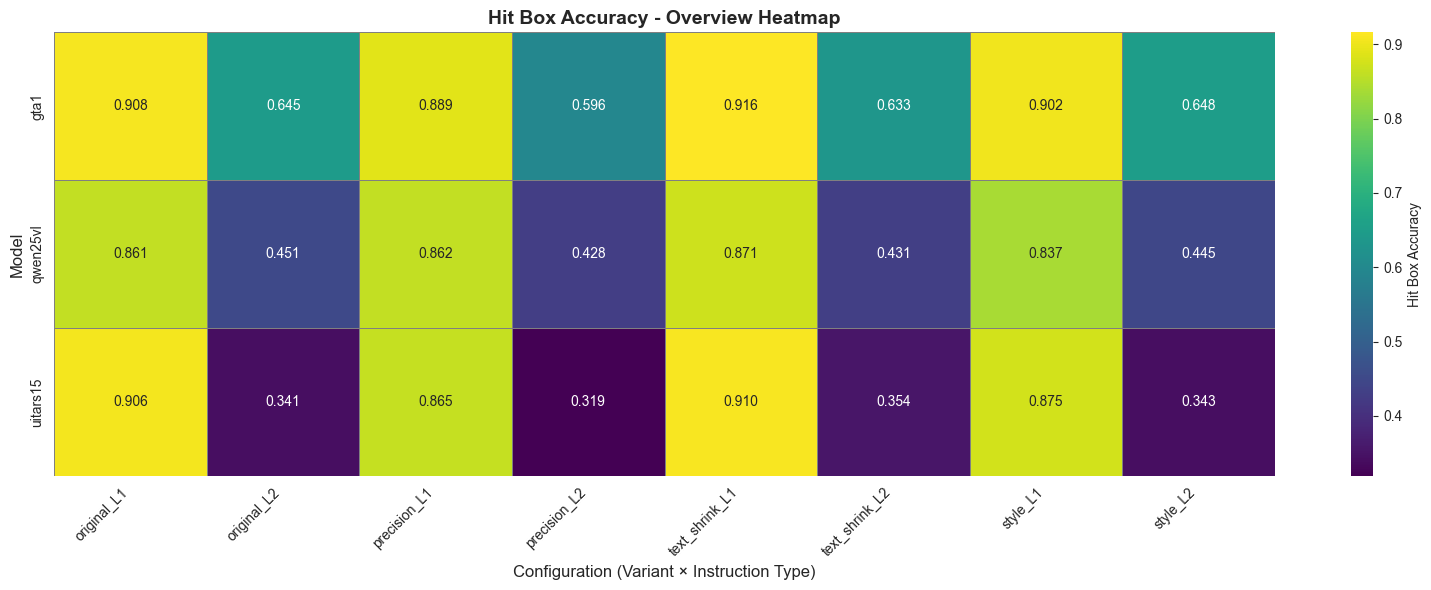

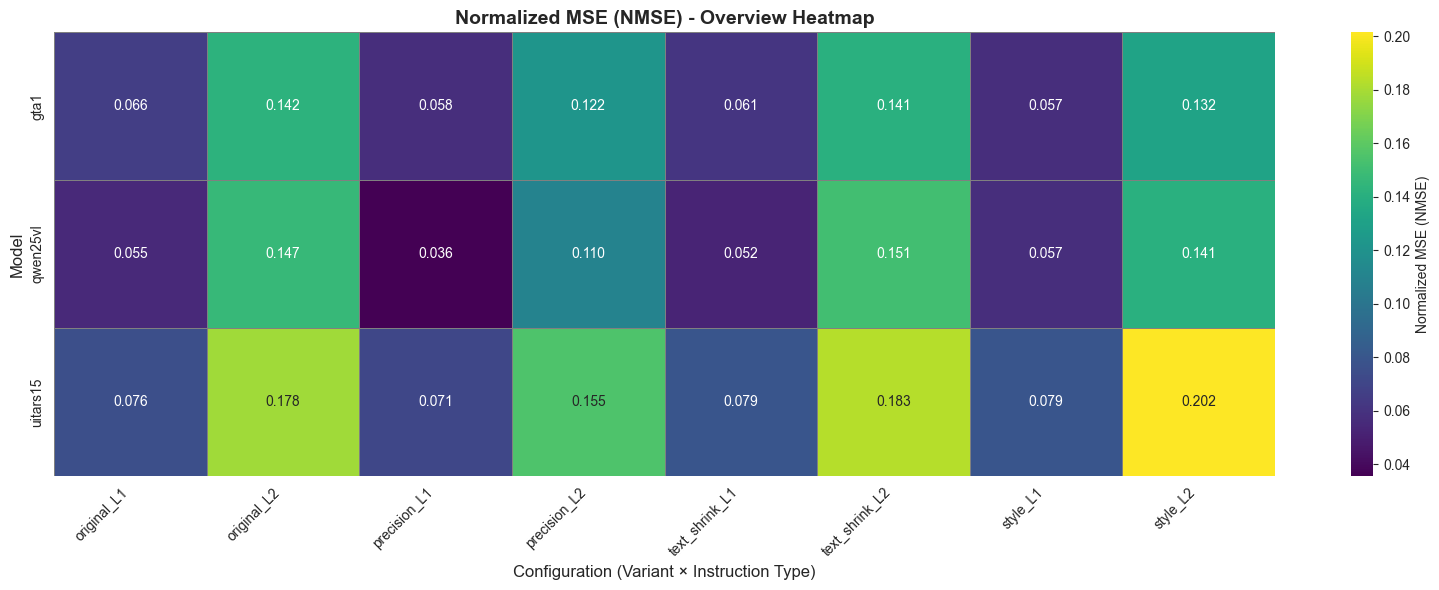

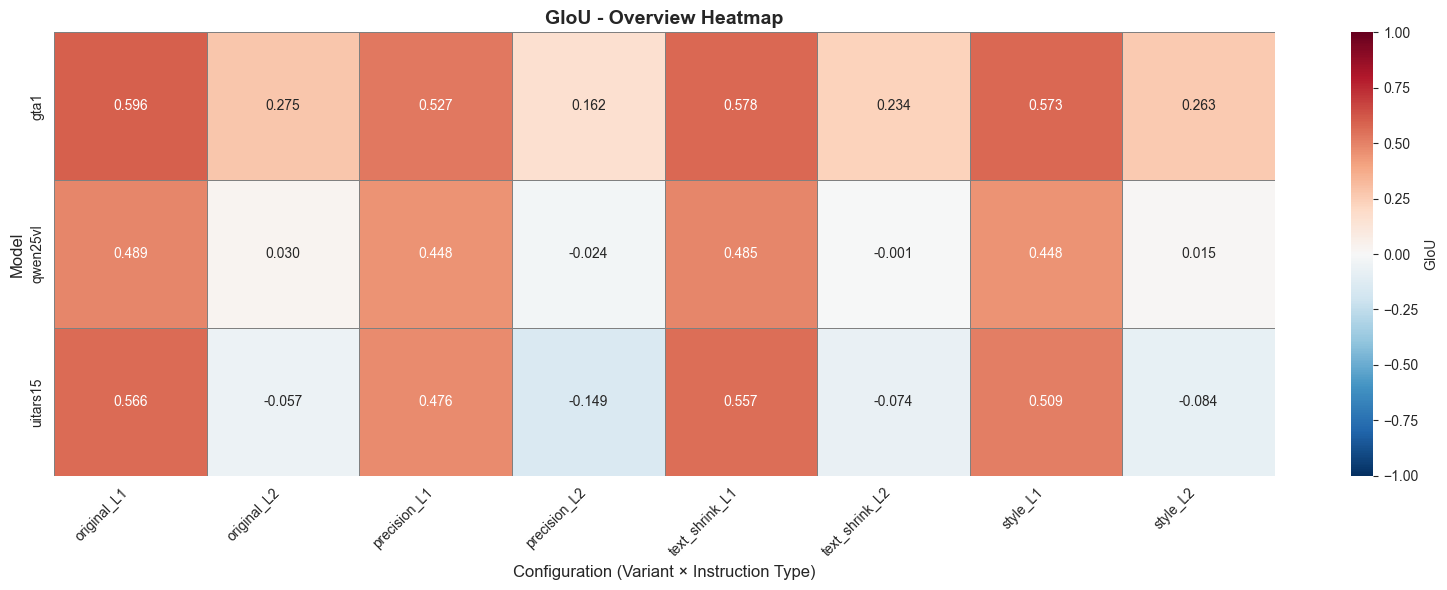

Overview heatmaps completed!


In [33]:
# ============================================================================
# 1. OVERVIEW HEATMAPS
# ============================================================================

# Prepare data for heatmaps: average over reasoning, group by model × (variant × level)
heatmap_data_list = []
for metric in ['hit_box_accuracy', 'normalized_mse', 'giou']:
    # Group by model, variant, level and average over reasoning
    heatmap_df = df.groupby(['model', 'variant', 'level'])[metric].mean().reset_index()
    
    # Create configuration labels: variant + level
    heatmap_df['config'] = heatmap_df['variant'] + '_' + heatmap_df['level']
    
    # Pivot to create heatmap matrix: rows=model, columns=config
    heatmap_pivot = heatmap_df.pivot_table(
        index='model', 
        columns='config', 
        values=metric,
        aggfunc='mean'
    )
    
    # Reorder columns: original_L1, original_L2, precision_L1, precision_L2, text_shrink_L1, text_shrink_L2, style_L1, style_L2
    variant_order = ['original', 'precision', 'text_shrink', 'style']
    level_order = ['L1', 'L2']
    column_order = [f'{v}_{l}' for v in variant_order for l in level_order]
    heatmap_pivot = heatmap_pivot.reindex(columns=[c for c in column_order if c in heatmap_pivot.columns])
    
    heatmap_data_list.append((metric, heatmap_pivot))

# Create heatmaps
fig_width = 16
fig_height = 6

for metric, heatmap_pivot in heatmap_data_list:
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Choose colormap (diverging for GIoU, sequential for others)
    if metric == 'giou':
        cmap = 'RdBu_r'  # Diverging colormap (red-blue reversed)
        center = 0.0
        vmin, vmax = -1, 1
    else:
        cmap = 'viridis'  # Sequential colormap
        center = None
        vmin, vmax = None, None
    
    # Create heatmap
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={'label': metric_labels.get(metric, metric)},
        ax=ax,
        linewidths=0.5,
        linecolor='gray'
    )
    
    ax.set_title(f'{metric_labels.get(metric, metric)} - Overview Heatmap', fontsize=14, fontweight='bold')
    ax.set_xlabel('Configuration (Variant × Instruction Type)', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    # Rotate x-axis labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

print("Overview heatmaps completed!")


# 2. Faceted Line Plots with Error Bars

Line plots showing how each model responds to dataset variations under different conditions, with 95% confidence intervals.


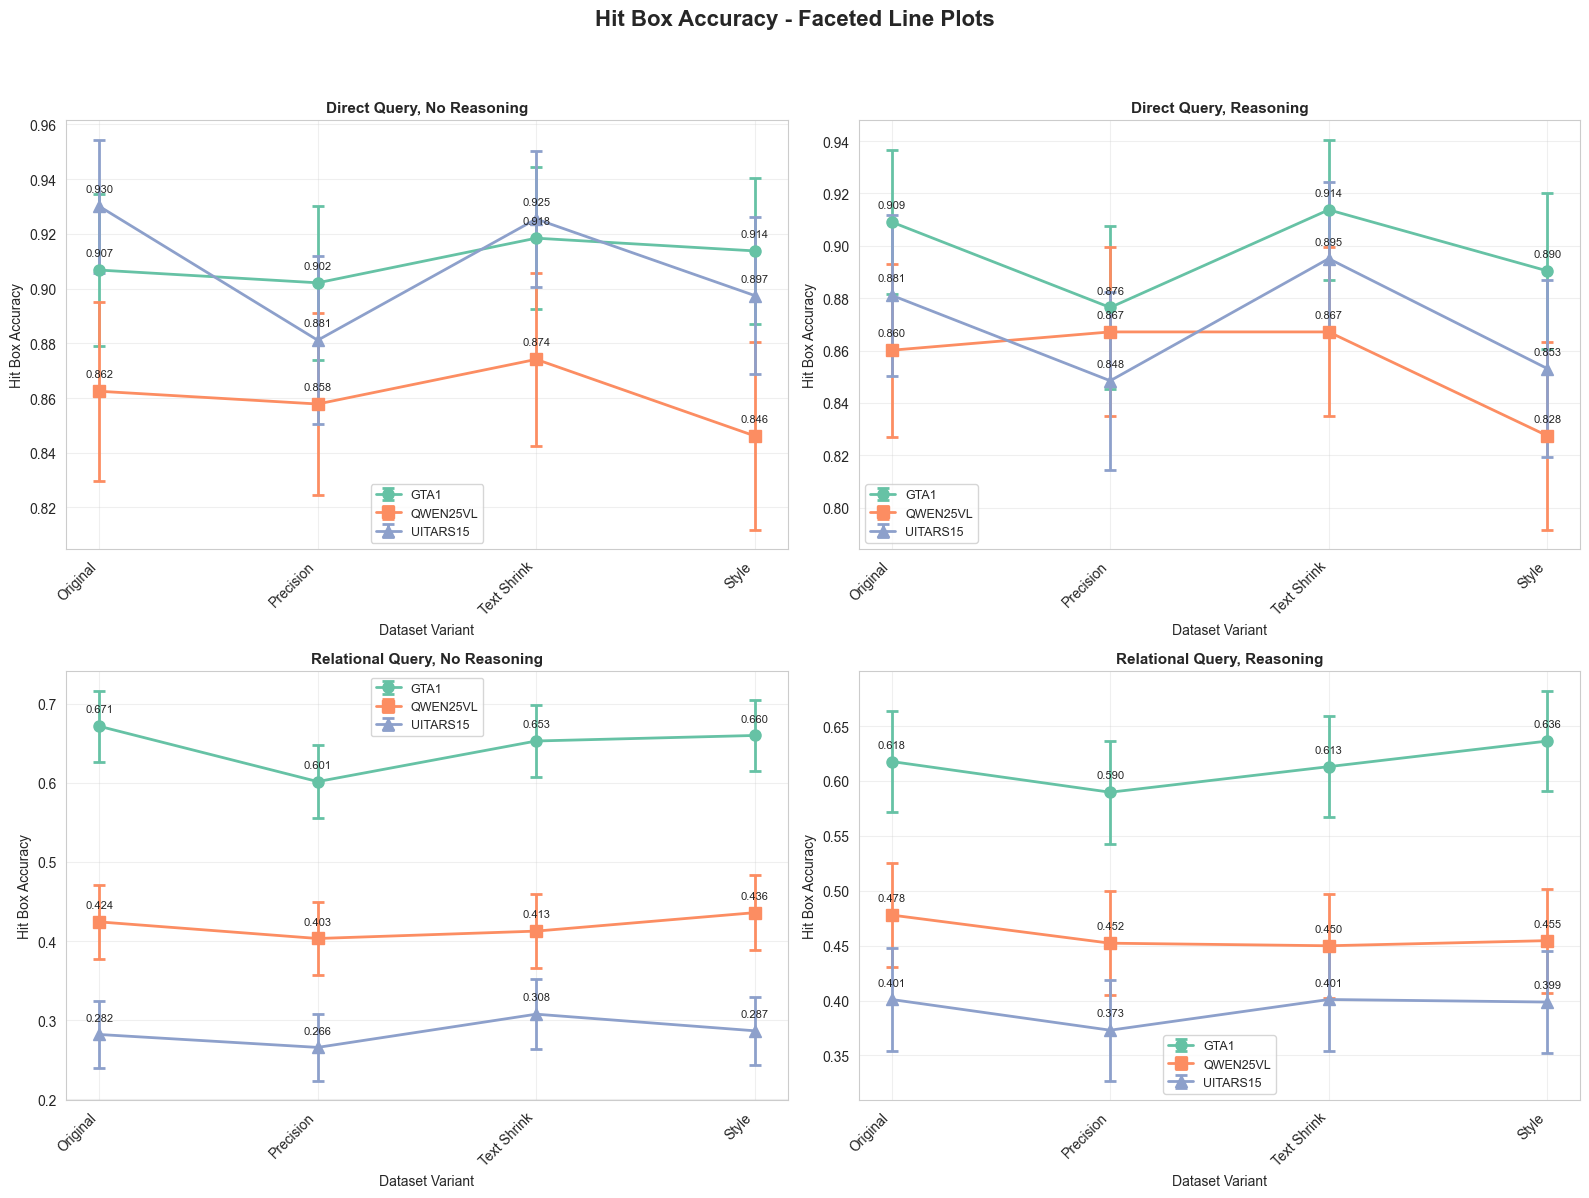

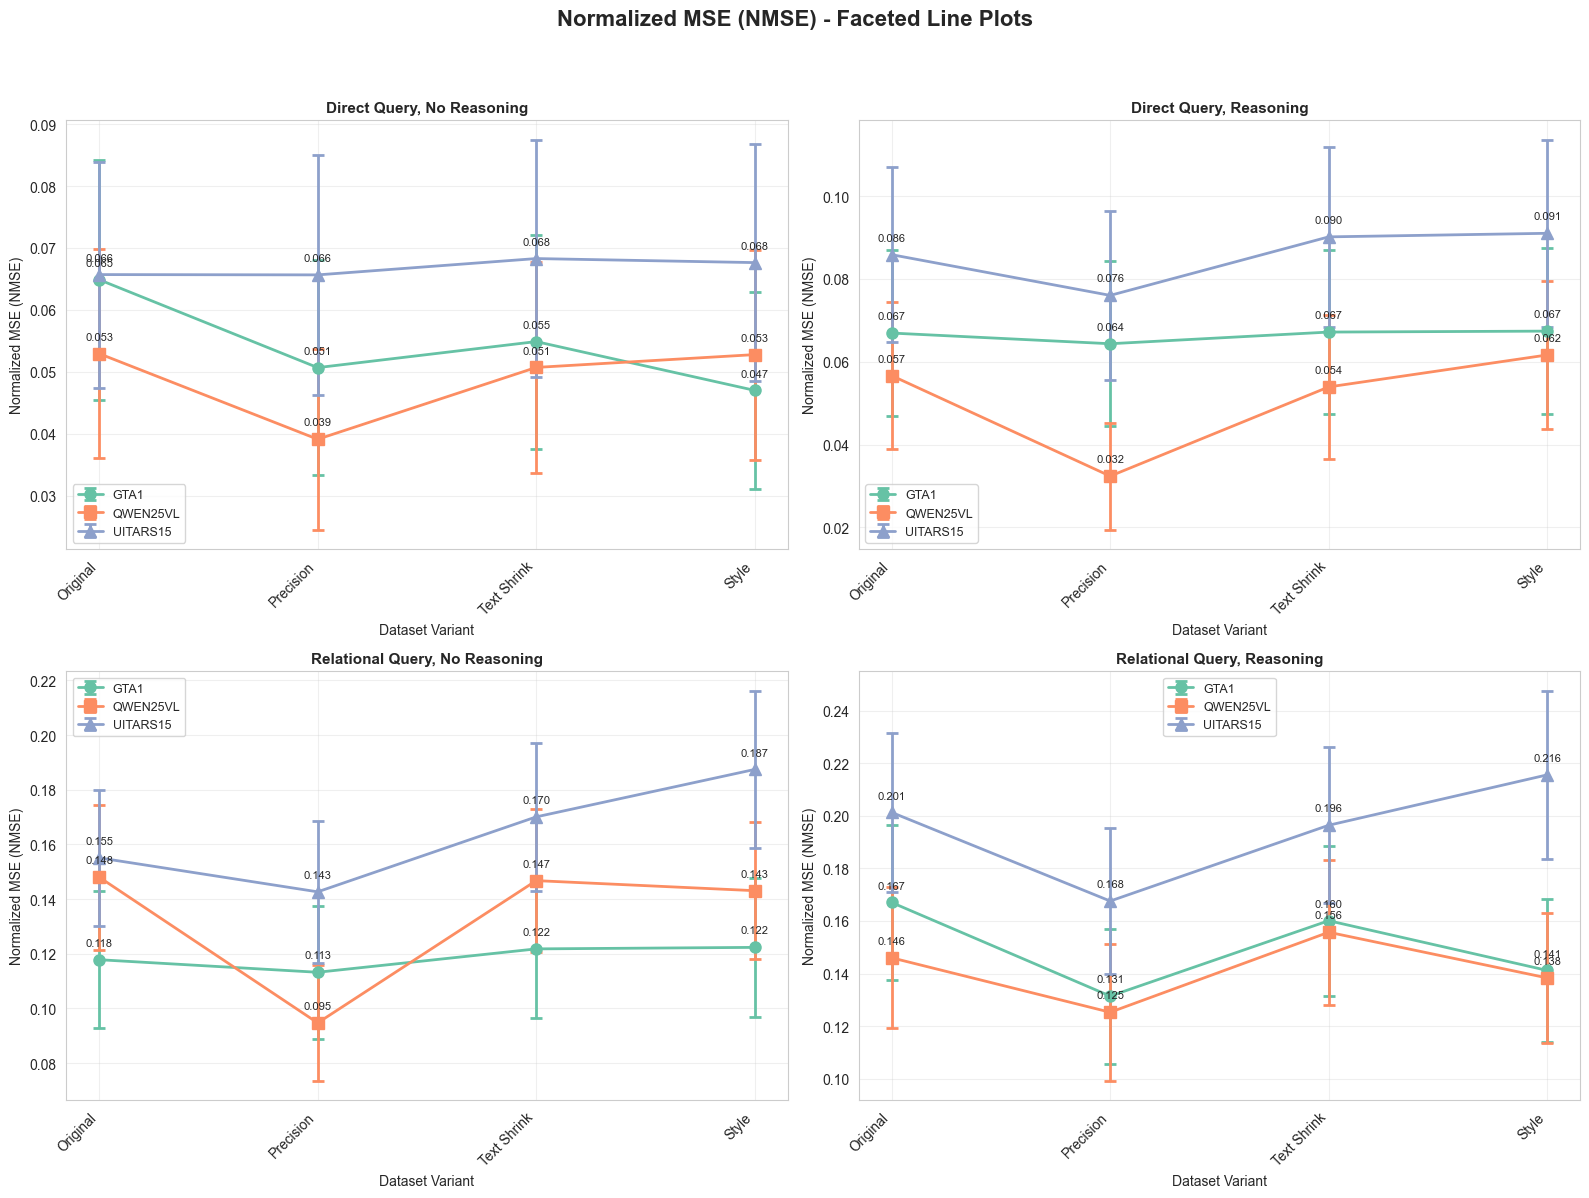

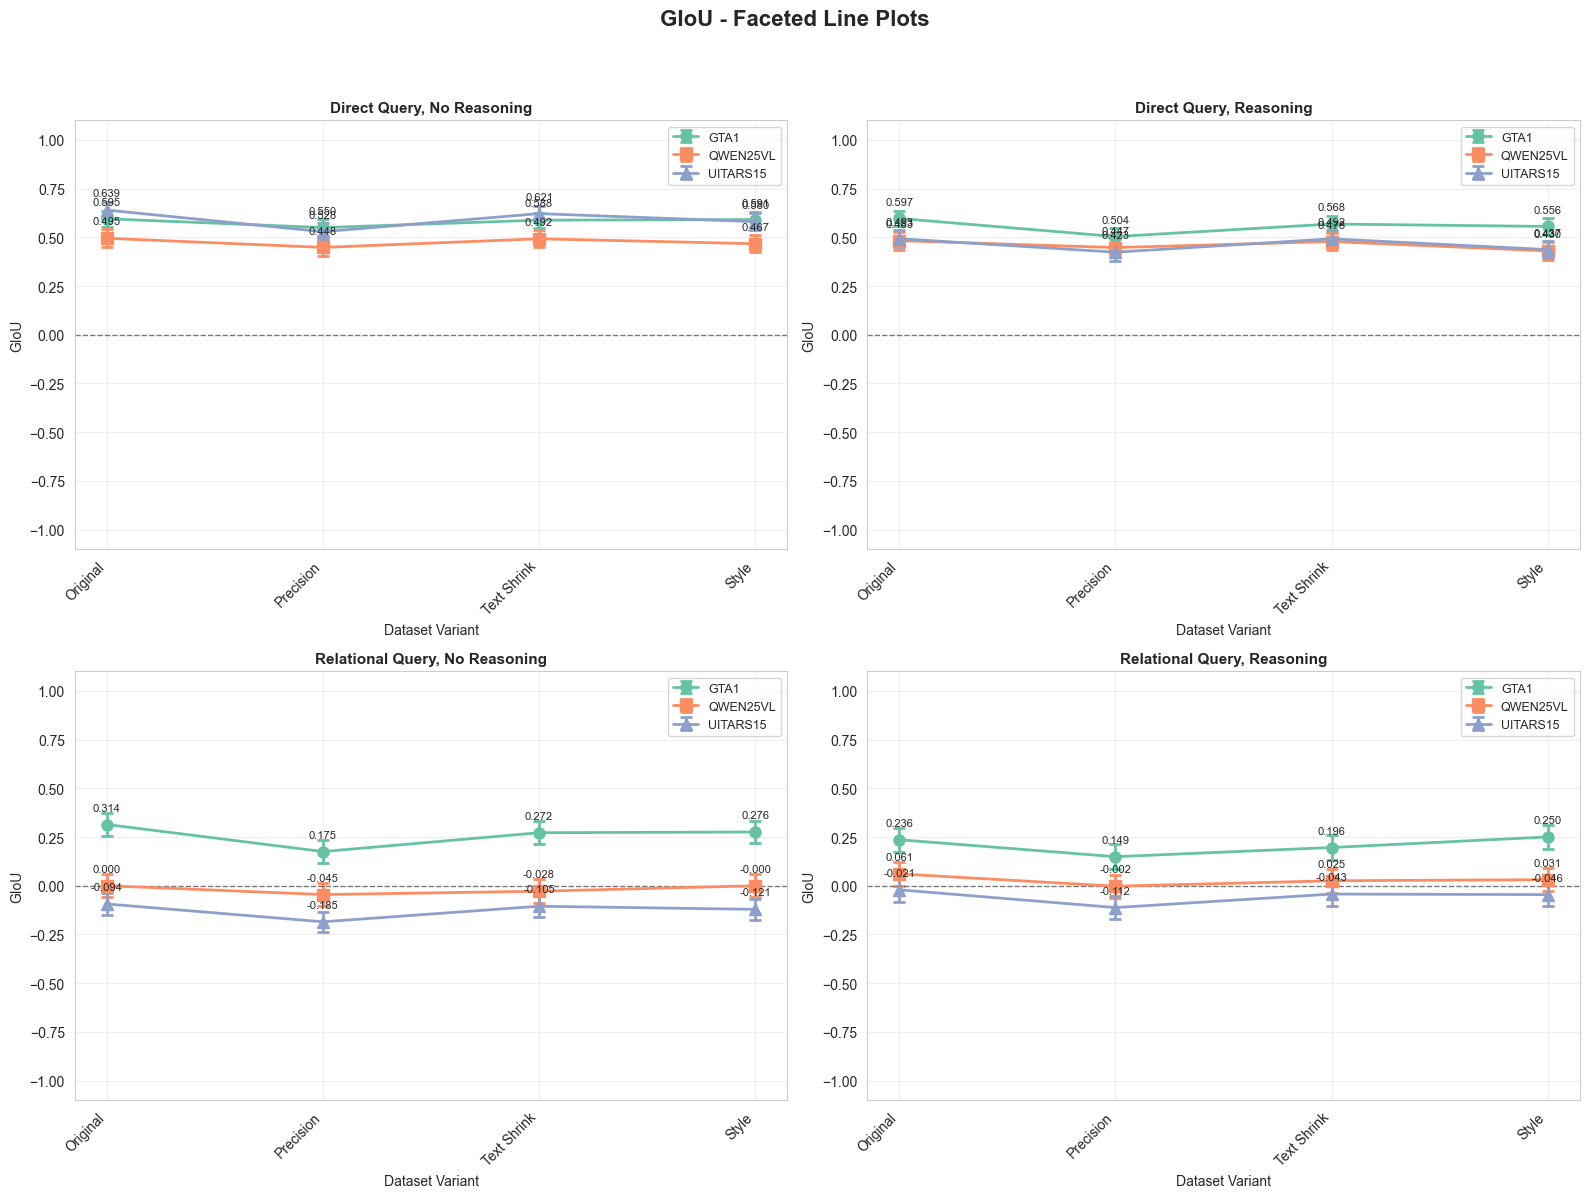

Faceted line plots completed!


In [34]:
# ============================================================================
# 2. FACETED LINE PLOTS WITH ERROR BARS
# ============================================================================

# Calculate mean and CI for each metric
variant_order = ['original', 'precision', 'text_shrink', 'style']
model_order = ['gta1', 'qwen25vl', 'uitars15']

for metric in ['hit_box_accuracy', 'normalized_mse', 'giou']:
    # Calculate statistics for each group
    results = []
    for (model, variant, level, reasoning), group in df.groupby(['model', 'variant', 'level', 'use_reasoning']):
        values = group[metric].dropna()
        if len(values) > 0:
            ci_lower, ci_upper = calculate_ci(values, metric_name=metric)
            results.append({
                'model': model,
                'variant': variant,
                'level': level,
                'use_reasoning': reasoning,
                'mean': np.nanmean(values),
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'std_err': stats.sem(values) if len(values) > 1 else 0
            })
    stats_df = pd.DataFrame(results)
    
    # Create faceted plot: 2×2 grid (level × use_reasoning)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{metric_labels.get(metric, metric)} - Faceted Line Plots', fontsize=16, fontweight='bold', y=0.995)
    
    # Create facets
    facet_configs = [
        (0, 0, 'L1', False, 'Direct Query, No Reasoning'),
        (0, 1, 'L1', True, 'Direct Query, Reasoning'),
        (1, 0, 'L2', False, 'Relational Query, No Reasoning'),
        (1, 1, 'L2', True, 'Relational Query, Reasoning')
    ]
    
    for row_idx, col_idx, level_val, reasoning_val, title in facet_configs:
        ax = axes[row_idx, col_idx]
        
        # Filter data for this facet
        facet_data = stats_df[
            (stats_df['level'] == level_val) & 
            (stats_df['use_reasoning'] == reasoning_val)
        ]
        
        # Plot each model
        markers = ['o', 's', '^']
        for i, model in enumerate(model_order):
            model_data = facet_data[facet_data['model'] == model].sort_values('variant', key=lambda x: x.map({v: i for i, v in enumerate(variant_order)}))
            
            if len(model_data) > 0:
                x_pos = np.arange(len(variant_order))
                y_vals = []
                y_err_lower = []
                y_err_upper = []
                
                for variant in variant_order:
                    variant_data = model_data[model_data['variant'] == variant]
                    if len(variant_data) > 0:
                        y_vals.append(variant_data['mean'].values[0])
                        ci_lower = variant_data['ci_lower'].values[0]
                        ci_upper = variant_data['ci_upper'].values[0]
                        mean_val = variant_data['mean'].values[0]
                        y_err_lower.append(mean_val - ci_lower if not np.isnan(ci_lower) else 0)
                        y_err_upper.append(ci_upper - mean_val if not np.isnan(ci_upper) else 0)
                    else:
                        y_vals.append(np.nan)
                        y_err_lower.append(0)
                        y_err_upper.append(0)
                
                # Plot line with error bars
                ax.errorbar(
                    x_pos, y_vals,
                    yerr=[y_err_lower, y_err_upper],
                    marker=markers[i],
                    label=model.upper(),
                    color=model_color_map[model],
                    linewidth=2,
                    markersize=8,
                    capsize=4,
                    capthick=2
                )
                
                # Annotate points
                for j, (x, y) in enumerate(zip(x_pos, y_vals)):
                    if not np.isnan(y):
                        ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                                  xytext=(0,10), ha='center', fontsize=8)
        
        ax.set_xticks(np.arange(len(variant_order)))
        ax.set_xticklabels([v.replace('_', ' ').title() for v in variant_order], rotation=45, ha='right')
        ax.set_xlabel('Dataset Variant', fontsize=10)
        ax.set_ylabel(metric_labels.get(metric, metric), fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        # Set y-axis range for GIoU
        if metric == 'giou':
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            ax.set_ylim(-1.1, 1.1)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("Faceted line plots completed!")


# 3. Delta from Baseline Plots

Grouped bar charts showing improvement/deterioration from the original variant baseline, with error bars.


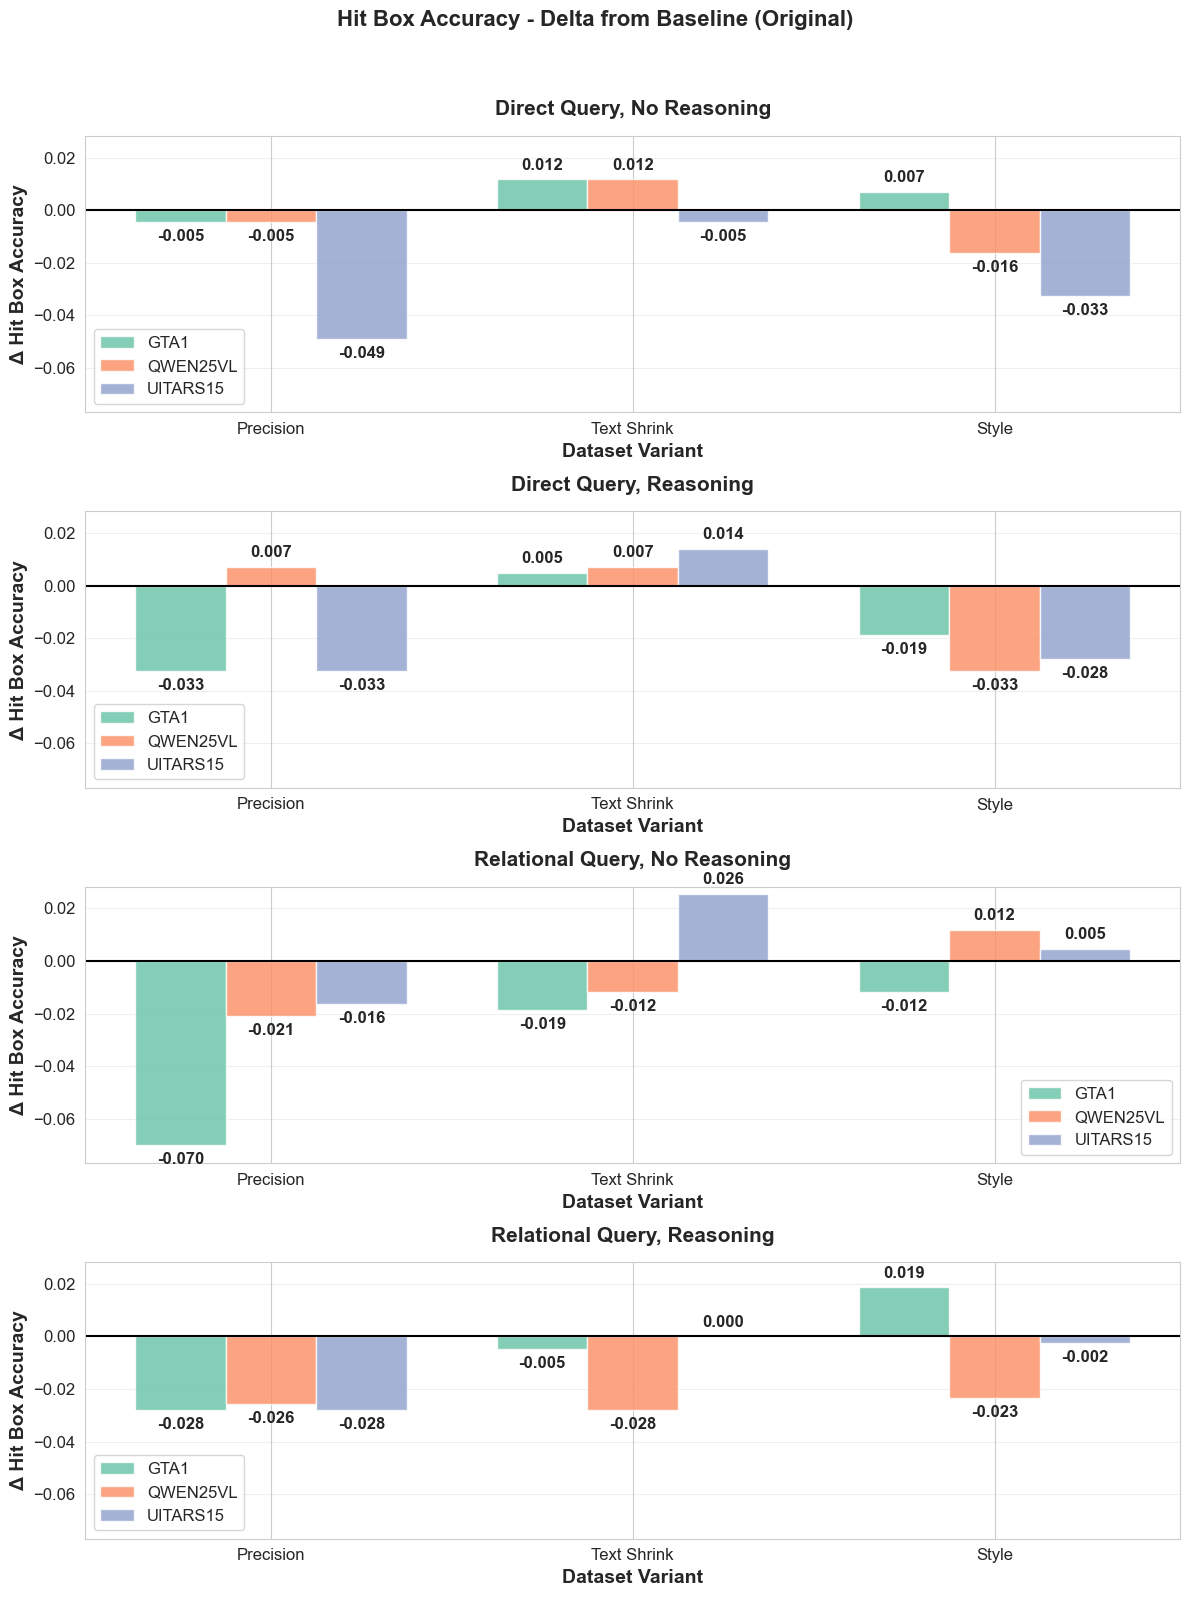

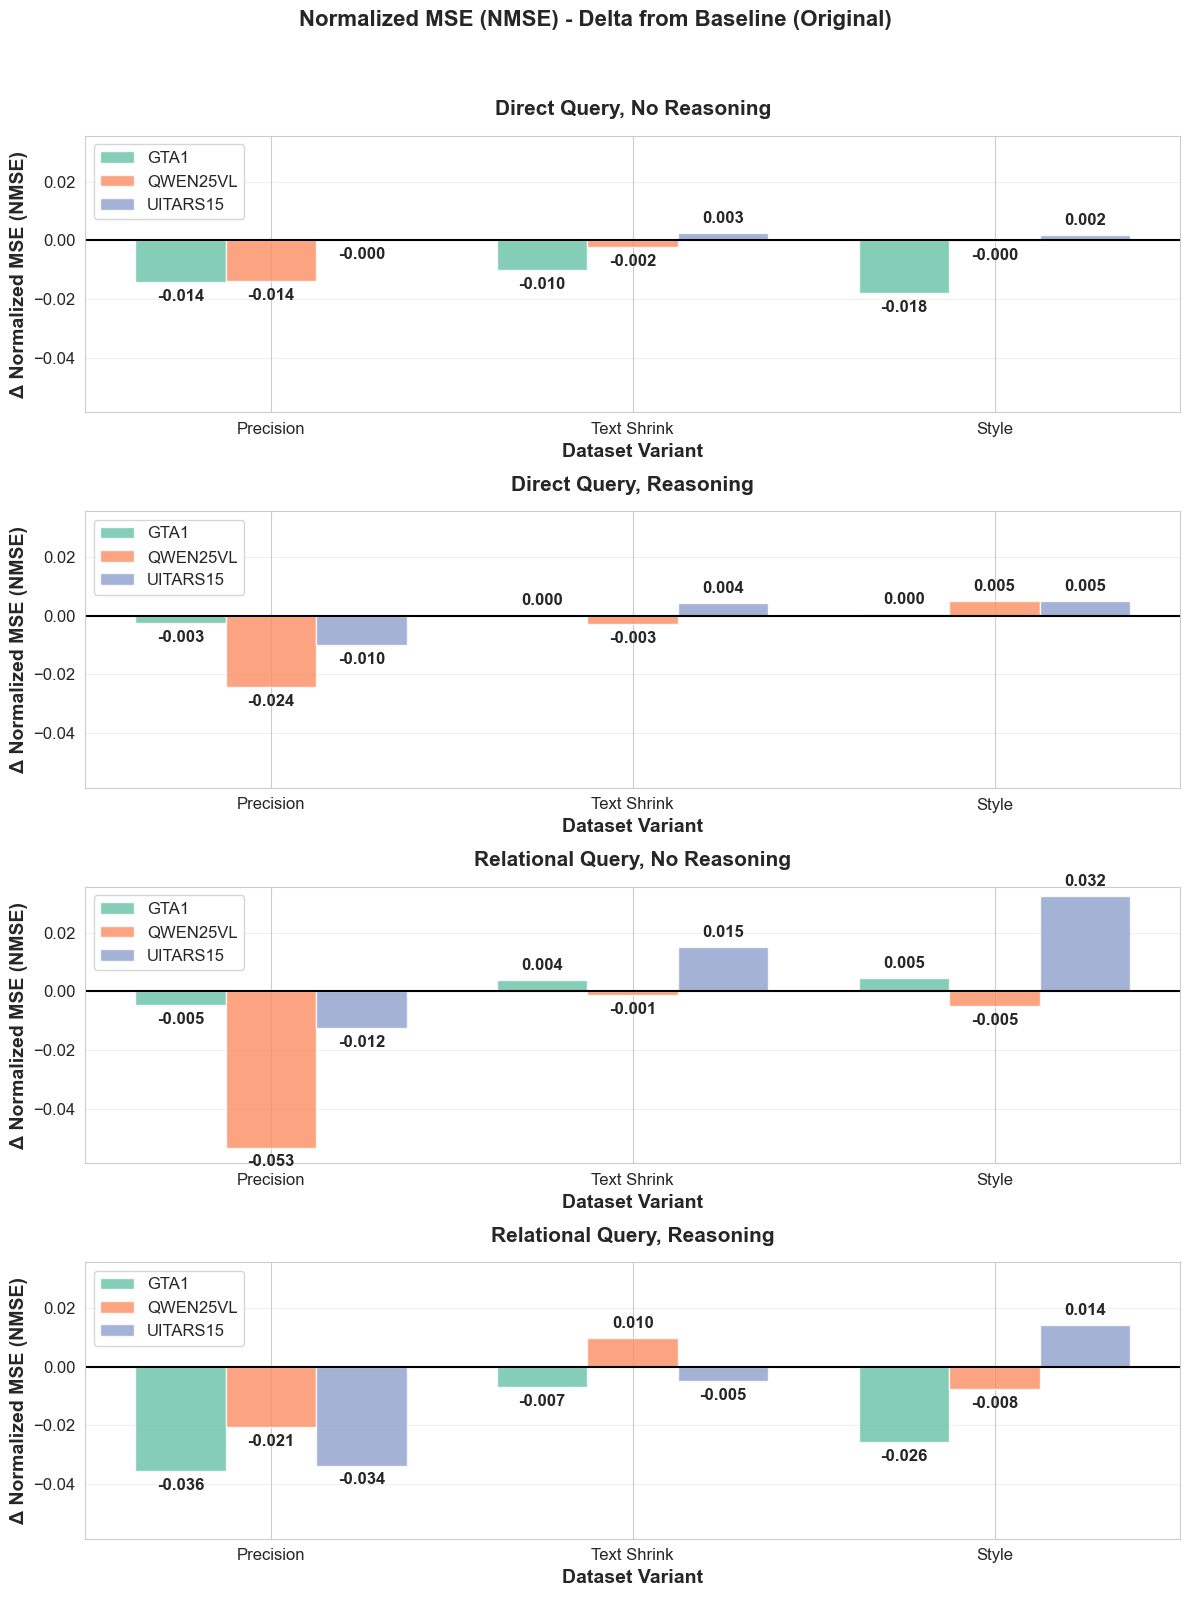

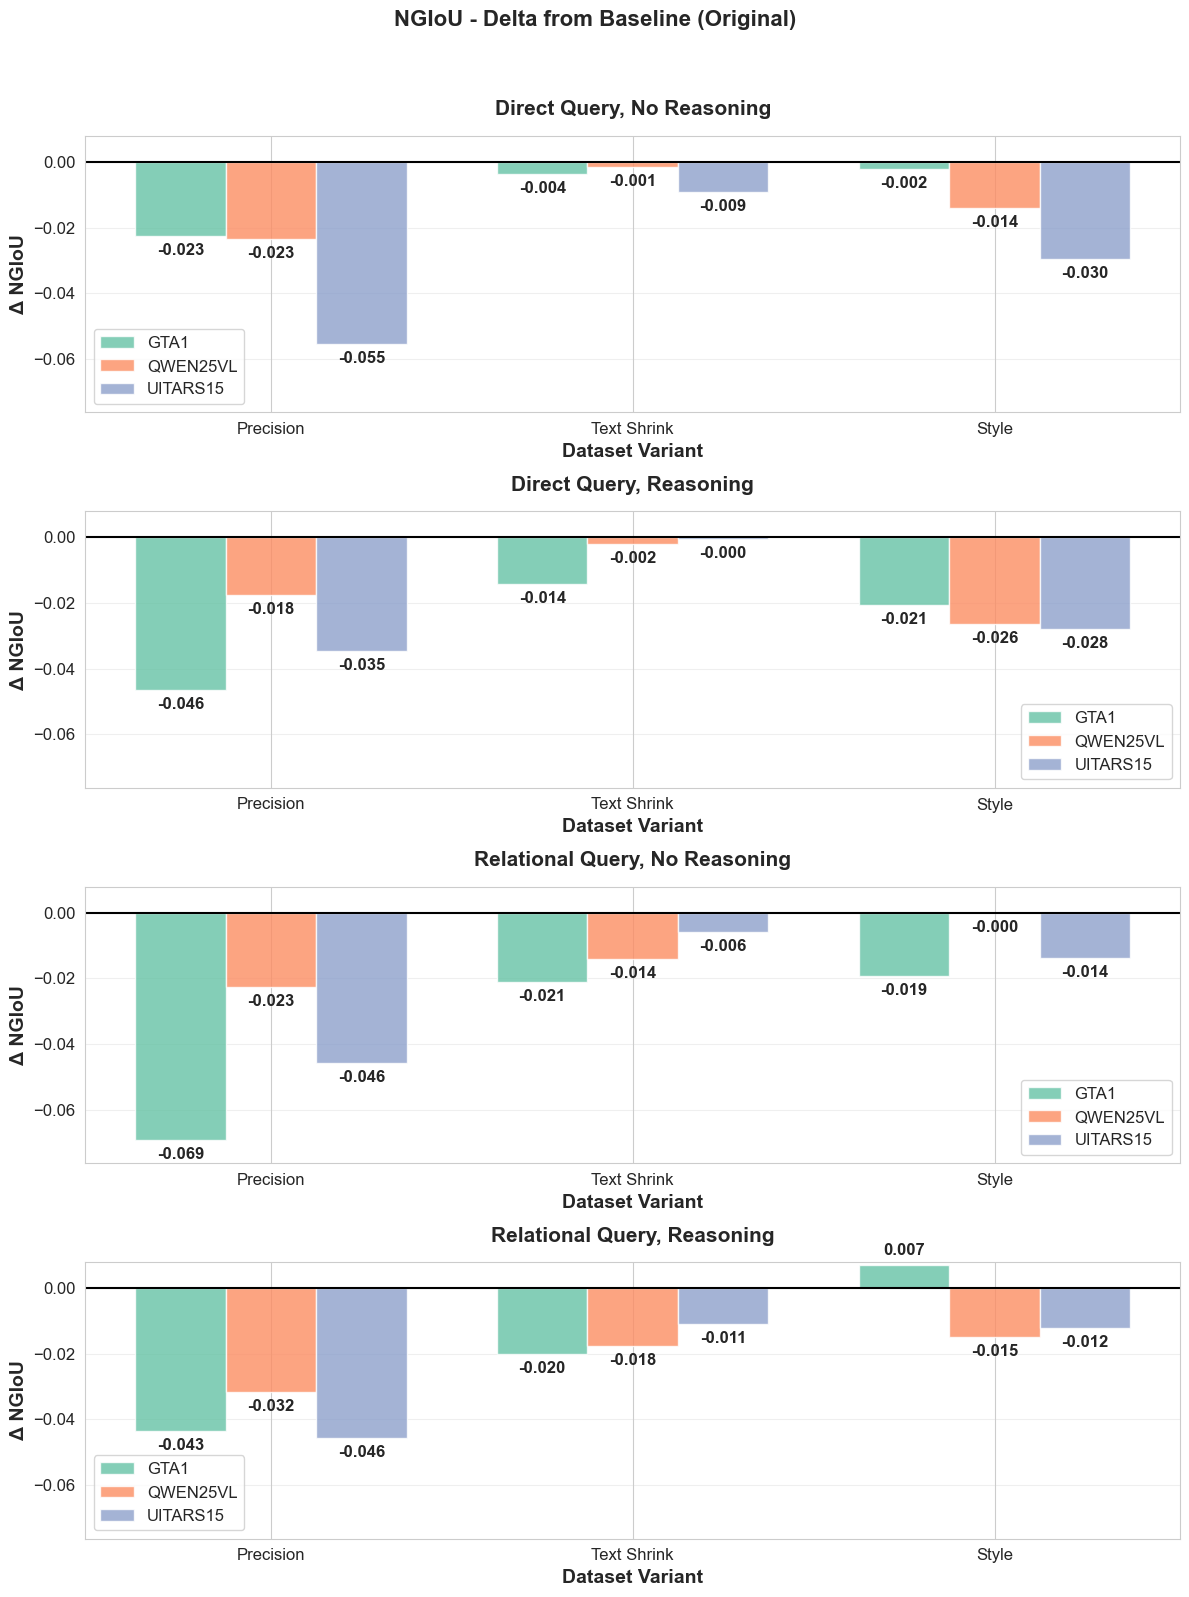

Delta from baseline plots completed!


In [37]:
# ============================================================================
# 3. DELTA FROM BASELINE PLOTS
# ============================================================================

# Calculate delta from original baseline for each configuration
non_original_variants = ['precision', 'text_shrink', 'style']

for metric in ['hit_box_accuracy', 'normalized_mse', 'ngiou']:
    # Calculate mean and CI for each group
    results = []
    for (model, variant, level, reasoning), group in df.groupby(['model', 'variant', 'level', 'use_reasoning']):
        values = group[metric].dropna()
        if len(values) > 0:
            ci_lower, ci_upper = calculate_ci(values, metric_name=metric)
            results.append({
                'model': model,
                'variant': variant,
                'level': level,
                'use_reasoning': reasoning,
                'mean': np.nanmean(values),
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'n': len(values)
            })
    stats_df = pd.DataFrame(results)
    
    # Calculate baseline (original) values
    baseline_df = stats_df[stats_df['variant'] == 'original'].copy()
    baseline_df = baseline_df.rename(columns={
        'mean': 'baseline_mean', 
        'ci_lower': 'baseline_ci_lower', 
        'ci_upper': 'baseline_ci_upper'
    })
    baseline_df = baseline_df[['model', 'level', 'use_reasoning', 'baseline_mean', 'baseline_ci_lower', 'baseline_ci_upper']]
    
    # Calculate delta for non-original variants
    delta_df = stats_df[stats_df['variant'].isin(non_original_variants)].copy()
    delta_df = delta_df.merge(baseline_df, on=['model', 'level', 'use_reasoning'], how='left')
    
    # Calculate delta (current - baseline)
    delta_df['delta'] = delta_df['mean'] - delta_df['baseline_mean']
    
    # Calculate global y-axis limits across all facets for consistent comparison
    all_deltas = delta_df['delta'].dropna()
    if len(all_deltas) > 0:
        y_min = min(0, all_deltas.min()) * 1.1  # Add 10% padding, ensure 0 is included
        y_max = max(0, all_deltas.max()) * 1.1
    else:
        y_min, y_max = -0.1, 0.1
    
    # Create faceted plot: 4 rows × 1 column (level × use_reasoning)
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    fig.suptitle(f'{metric_labels.get(metric, metric)} - Delta from Baseline (Original)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Ensure axes is always a list/array
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()
    
    facet_configs = [
        (0, 'L1', False, 'Direct Query, No Reasoning'),
        (1, 'L1', True, 'Direct Query, Reasoning'),
        (2, 'L2', False, 'Relational Query, No Reasoning'),
        (3, 'L2', True, 'Relational Query, Reasoning')
    ]
    
    for row_idx, level_val, reasoning_val, title in facet_configs:
        ax = axes[row_idx]
        
        # Filter data for this facet
        facet_data = delta_df[
            (delta_df['level'] == level_val) & 
            (delta_df['use_reasoning'] == reasoning_val)
        ]
        
        # Prepare data for grouped bar chart
        x = np.arange(len(non_original_variants))
        width = 0.25  # Width of bars
        model_positions = [-width, 0, width]
        
        for i, model in enumerate(model_order):
            model_data = facet_data[facet_data['model'] == model]
            
            deltas = []
            
            for variant in non_original_variants:
                variant_data = model_data[model_data['variant'] == variant]
                if len(variant_data) > 0:
                    delta_val = variant_data['delta'].values[0]
                    deltas.append(delta_val)
                else:
                    deltas.append(np.nan)
            
            # Plot bars without error bars
            bars = ax.bar(
                x + model_positions[i], deltas,
                width, label=model.upper(),
                color=model_color_map[model],
                alpha=0.8
            )
            
            # Annotate bars with delta values
            for j, (bar, delta) in enumerate(zip(bars, deltas)):
                if not np.isnan(delta):
                    height = bar.get_height()
                    # Position text above bar if positive, below if negative
                    y_offset = 5 if height >= 0 else -5
                    ax.annotate(f'{delta:.3f}',
                              xy=(bar.get_x() + bar.get_width() / 2, height),
                              xytext=(0, y_offset),
                              textcoords="offset points",
                              ha='center', va='bottom' if height >= 0 else 'top',
                              fontsize=12, fontweight='bold')
        
        ax.set_xticks(x)
        ax.set_xticklabels([v.replace('_', ' ').title() for v in non_original_variants], fontsize=13)
        ax.set_xlabel('Dataset Variant', fontsize=14, fontweight='bold')
        ax.set_ylabel(f'Δ {metric_labels.get(metric, metric)}', fontsize=14, fontweight='bold')
        ax.set_title(title, fontsize=15, fontweight='bold', pad=15)  # Increased pad to prevent overlap
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(loc='best', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=12)
        
        # Set consistent y-axis limits across all subplots
        ax.set_ylim(bottom=y_min, top=y_max)
    
    plt.subplots_adjust(hspace=0.4)  # Increased hspace to prevent title overlap
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

print("Delta from baseline plots completed!")

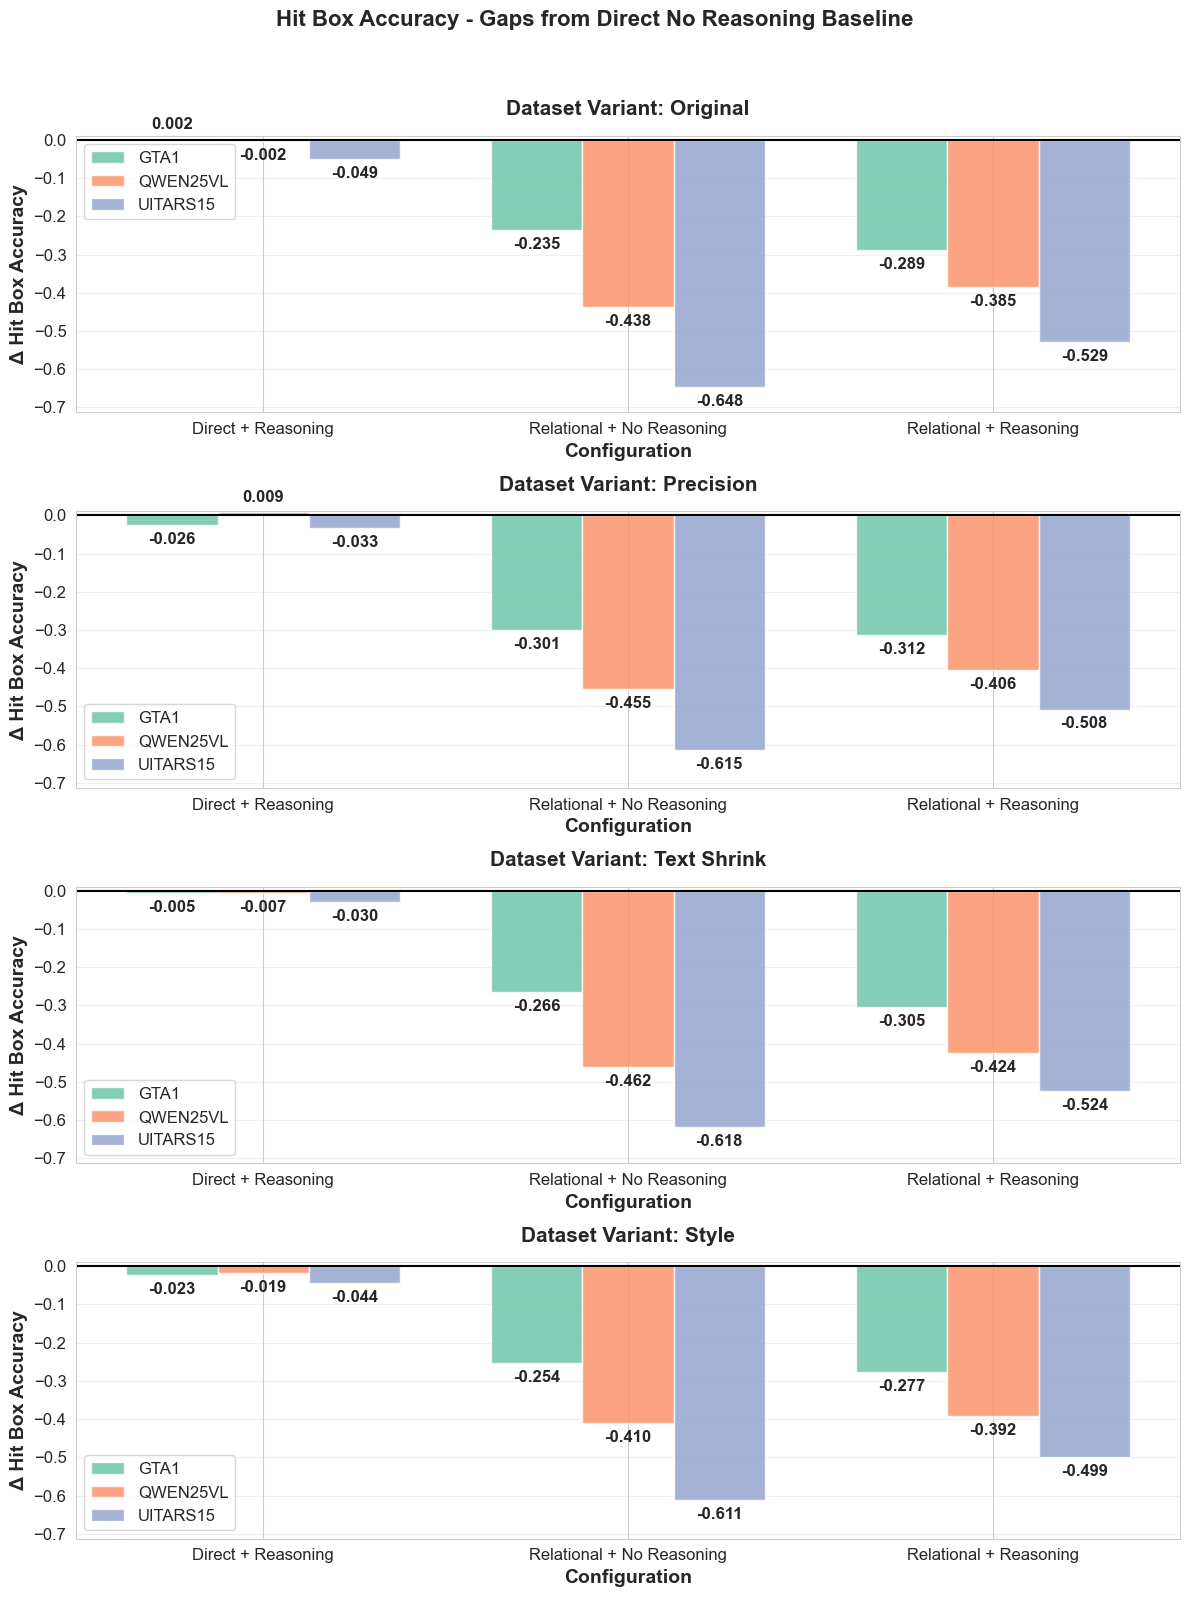

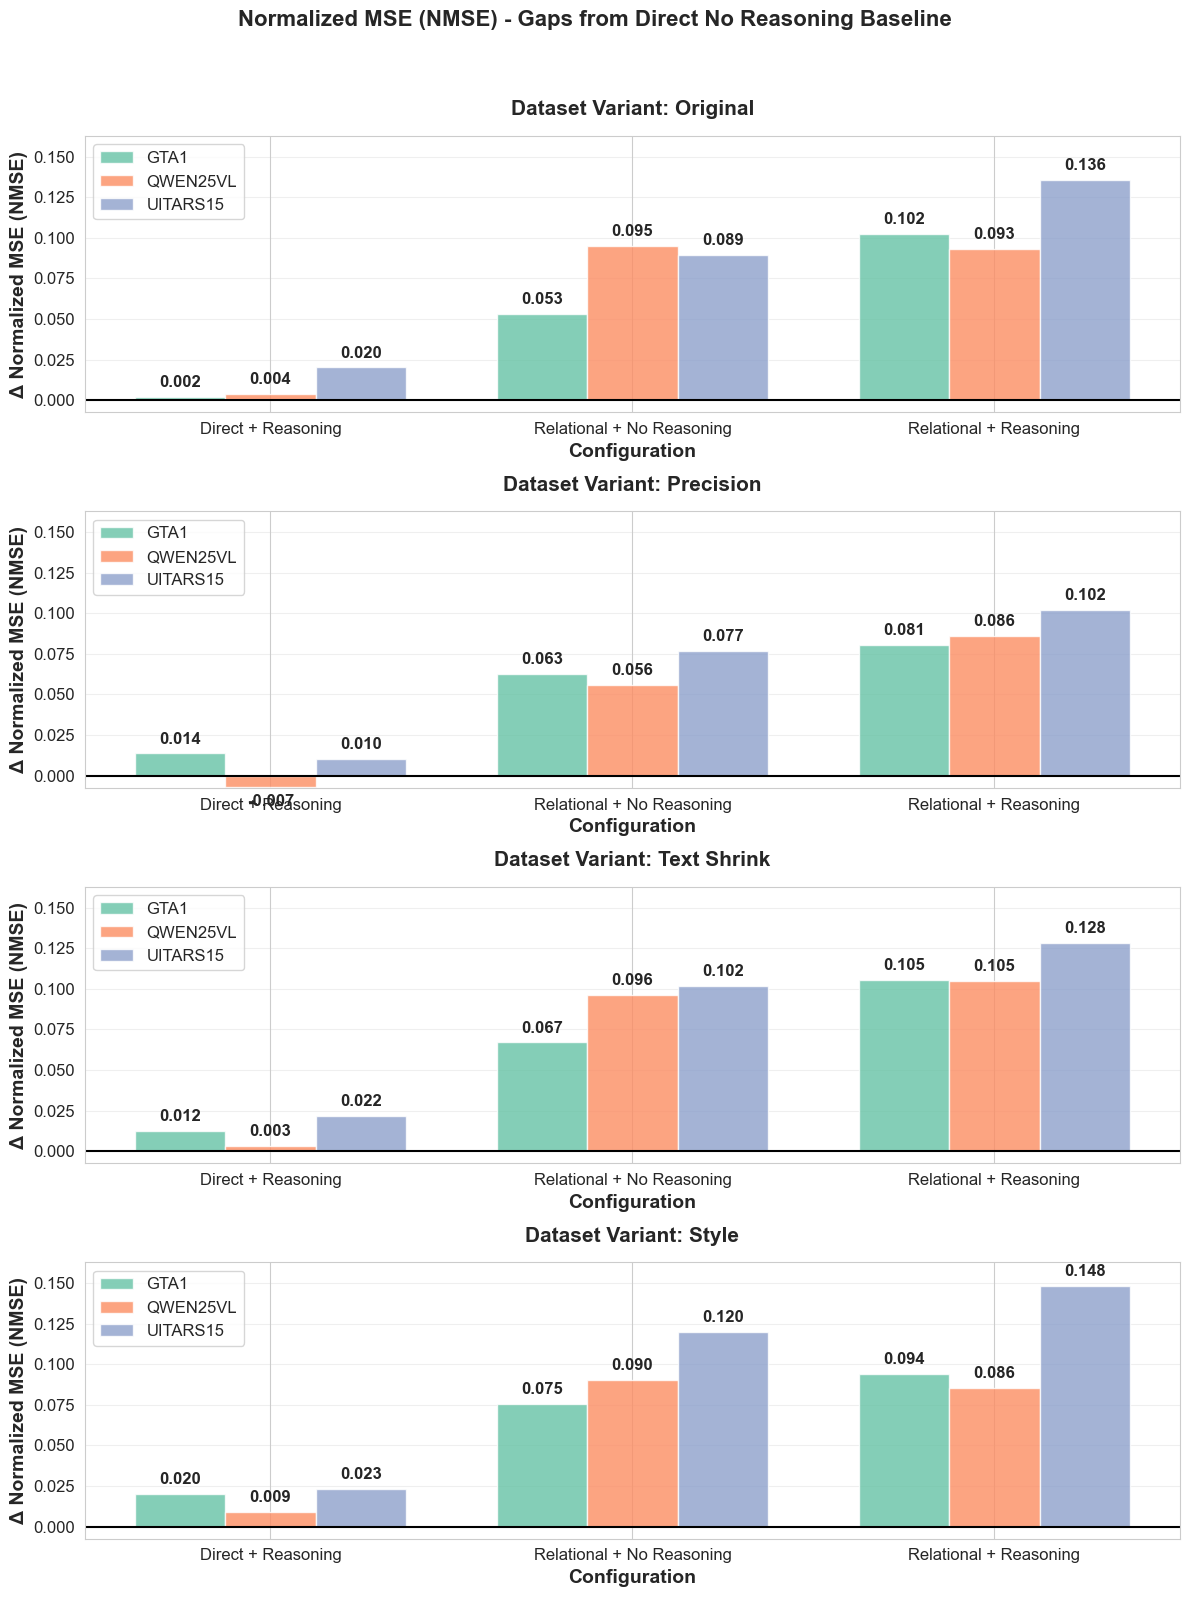

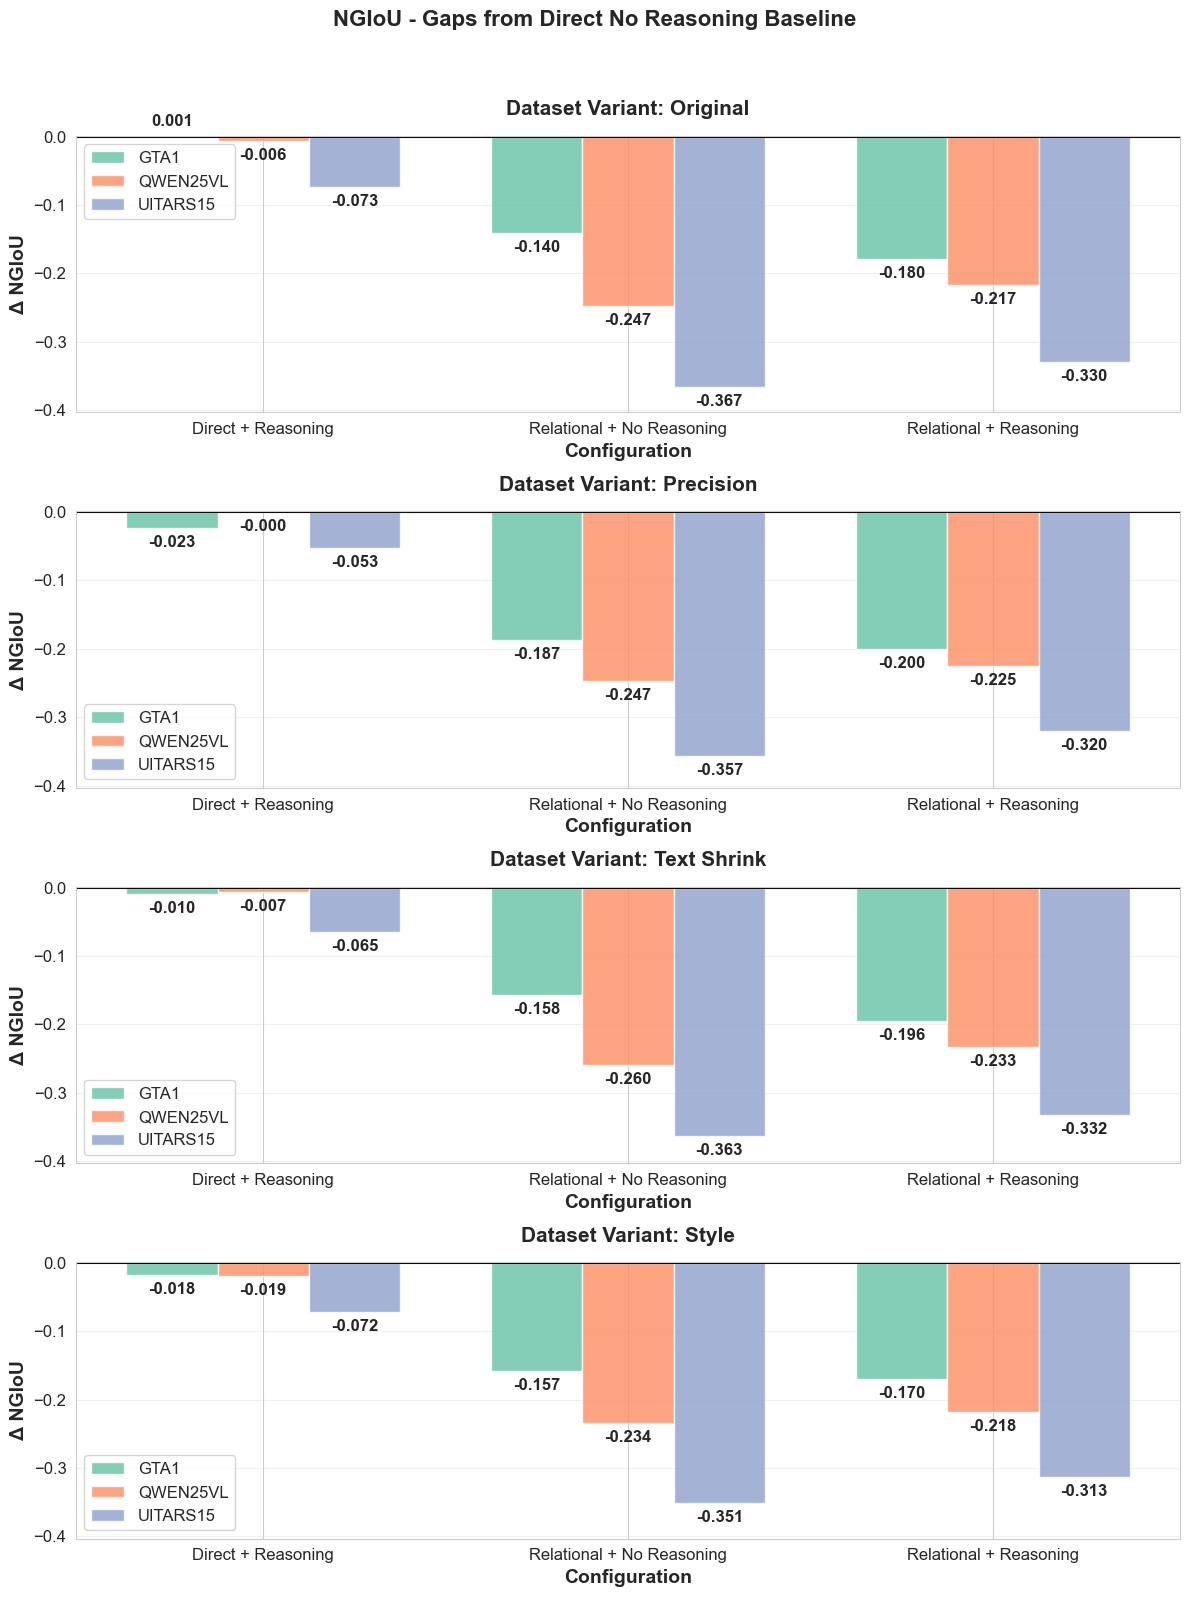

Gaps visualization plots completed!


In [38]:
# ============================================================================
# 4. GAPS BETWEEN REASONING/NO REASONING AND DIRECT/RELATIONAL
# ============================================================================
# For each dataset variant, show gaps between:
# - Direct Reasoning vs Direct No Reasoning
# - Relational No Reasoning vs Direct No Reasoning  
# - Relational Reasoning vs Direct No Reasoning
# Baseline: Direct No Reasoning (not shown on x-axis)

all_variants = ['original', 'precision', 'text_shrink', 'style']

for metric in ['hit_box_accuracy', 'normalized_mse', 'ngiou']:
    # Calculate mean and CI for each group
    results = []
    for (model, variant, level, reasoning), group in df.groupby(['model', 'variant', 'level', 'use_reasoning']):
        values = group[metric].dropna()
        if len(values) > 0:
            ci_lower, ci_upper = calculate_ci(values, metric_name=metric)
            results.append({
                'model': model,
                'variant': variant,
                'level': level,
                'use_reasoning': reasoning,
                'mean': np.nanmean(values),
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'n': len(values)
            })
    stats_df = pd.DataFrame(results)
    
    # Calculate baseline: L1 (direct), no reasoning for each variant (per model)
    baseline_df = stats_df[
        (stats_df['level'] == 'L1') & 
        (stats_df['use_reasoning'] == False)
    ].copy()
    baseline_df = baseline_df.rename(columns={
        'mean': 'baseline_mean', 
        'ci_lower': 'baseline_ci_lower', 
        'ci_upper': 'baseline_ci_upper'
    })
    baseline_df = baseline_df[['model', 'variant', 'baseline_mean', 'baseline_ci_lower', 'baseline_ci_upper']]
    
    # Calculate delta for configurations to compare (excluding baseline itself)
    # We want: L1 Reasoning, L2 No Reasoning, L2 Reasoning
    comparison_configs = [
        ('L1', True, 'Direct + Reasoning'),
        ('L2', False, 'Relational + No Reasoning'),
        ('L2', True, 'Relational + Reasoning')
    ]
    
    # Prepare data for plotting
    plot_data = []
    for variant in all_variants:
        variant_baseline = baseline_df[baseline_df['variant'] == variant]
        variant_stats = stats_df[stats_df['variant'] == variant]
        
        for model in model_order:
            model_baseline = variant_baseline[variant_baseline['model'] == model]
            if len(model_baseline) == 0:
                continue
                
            baseline_val = model_baseline['baseline_mean'].values[0]
            
            for level, reasoning, label in comparison_configs:
                config_stats = variant_stats[
                    (variant_stats['model'] == model) &
                    (variant_stats['level'] == level) &
                    (variant_stats['use_reasoning'] == reasoning)
                ]
                
                if len(config_stats) > 0:
                    delta = config_stats['mean'].values[0] - baseline_val
                    plot_data.append({
                        'variant': variant,
                        'model': model,
                        'config': label,
                        'delta': delta
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Calculate global y-axis limits across all facets for consistent comparison
    all_deltas = plot_df['delta'].dropna()
    if len(all_deltas) > 0:
        y_min = min(0, all_deltas.min()) * 1.1  # Add 10% padding, ensure 0 is included
        y_max = max(0, all_deltas.max()) * 1.1
    else:
        y_min, y_max = -0.1, 0.1
    
    # Create faceted plot: 4 rows × 1 column (one for each dataset variant)
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    fig.suptitle(f'{metric_labels.get(metric, metric)} - Gaps from Direct No Reasoning Baseline', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Ensure axes is always a list/array
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()
    
    config_labels = [label for _, _, label in comparison_configs]
    
    for row_idx, variant in enumerate(all_variants):
        ax = axes[row_idx]
        
        # Filter data for this variant
        variant_data = plot_df[plot_df['variant'] == variant]
        
        # Prepare data for grouped bar chart
        x = np.arange(len(config_labels))
        width = 0.25  # Width of bars
        model_positions = [-width, 0, width]
        
        for i, model in enumerate(model_order):
            model_data = variant_data[variant_data['model'] == model]
            
            deltas = []
            for label in config_labels:
                config_data = model_data[model_data['config'] == label]
                if len(config_data) > 0:
                    delta_val = config_data['delta'].values[0]
                    deltas.append(delta_val)
                else:
                    deltas.append(np.nan)
            
            # Plot bars
            bars = ax.bar(
                x + model_positions[i], deltas,
                width, label=model.upper(),
                color=model_color_map[model],
                alpha=0.8
            )
            
            # Annotate bars with delta values
            for j, (bar, delta) in enumerate(zip(bars, deltas)):
                if not np.isnan(delta):
                    height = bar.get_height()
                    # Position text above bar if positive, below if negative
                    y_offset = 5 if height >= 0 else -5
                    ax.annotate(f'{delta:.3f}',
                              xy=(bar.get_x() + bar.get_width() / 2, height),
                              xytext=(0, y_offset),
                              textcoords="offset points",
                              ha='center', va='bottom' if height >= 0 else 'top',
                              fontsize=12, fontweight='bold')
        
        ax.set_xticks(x)
        ax.set_xticklabels(config_labels, fontsize=13)
        ax.set_xlabel('Configuration', fontsize=14, fontweight='bold')
        ax.set_ylabel(f'Δ {metric_labels.get(metric, metric)}', fontsize=14, fontweight='bold')
        ax.set_title(f'Dataset Variant: {variant.replace("_", " ").title()}', fontsize=15, fontweight='bold', pad=15)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(loc='best', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=12)
        
        # Set consistent y-axis limits across all subplots
        ax.set_ylim(bottom=y_min, top=y_max)
    
    plt.subplots_adjust(hspace=0.4)  # Increased hspace to prevent title overlap
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

print("Gaps visualization plots completed!")


# 5. Model Comparison Summary

Multi-panel plot showing average performance across all configurations for each model.


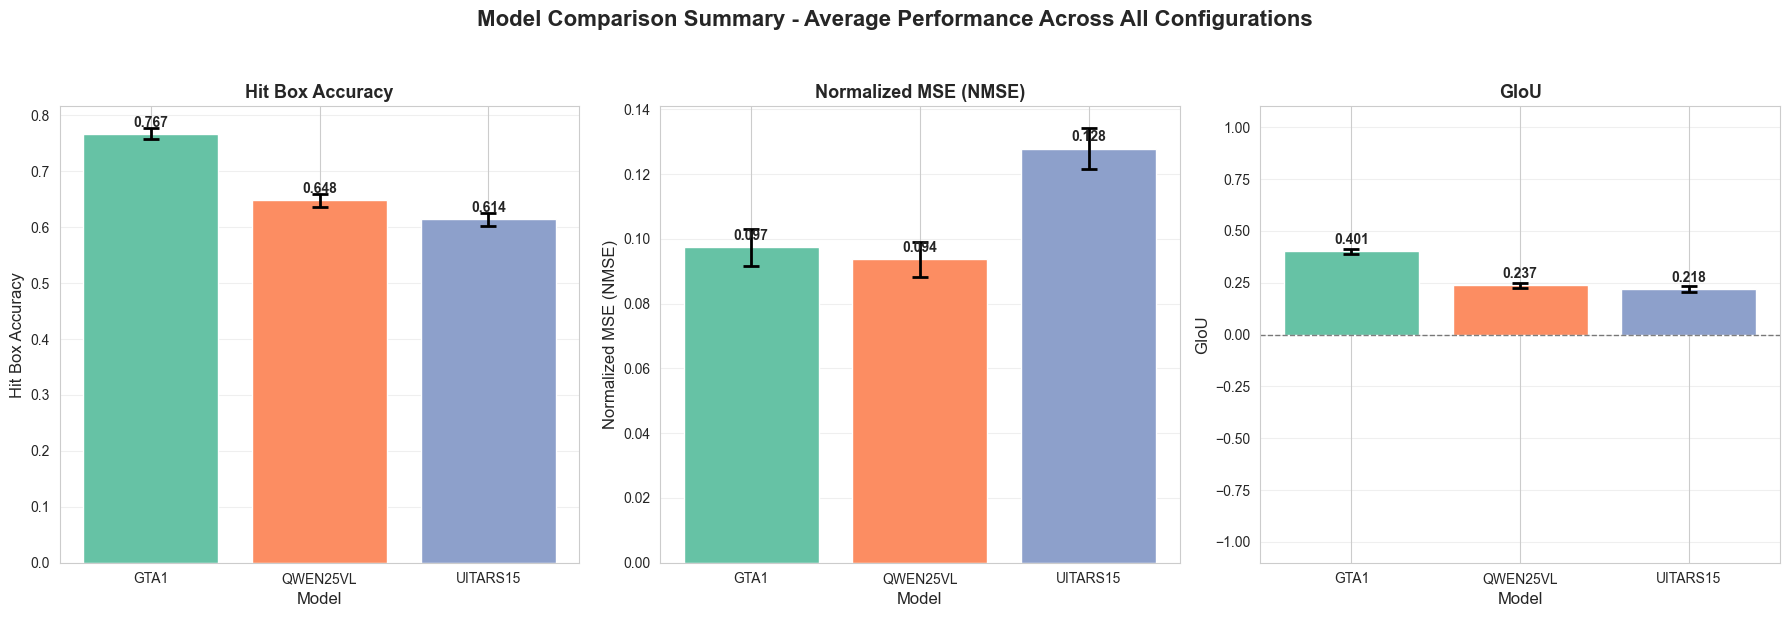

Model comparison summary completed!


In [ ]:
# ============================================================================
# 5. MODEL COMPARISON SUMMARY
# ============================================================================

# Calculate overall statistics across all configurations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison Summary - Average Performance Across All Configurations', 
             fontsize=16, fontweight='bold', y=1.02)

metrics = ['hit_box_accuracy', 'normalized_mse', 'giou']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Calculate mean and CI for each model across all configurations
    results = []
    for model, group in df.groupby('model'):
        values = group[metric].dropna()
        if len(values) > 0:
            ci_lower, ci_upper = calculate_ci(values, metric_name=metric)
            results.append({
                'model': model,
                'mean': np.nanmean(values),
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'std': np.nanstd(values)
            })
    model_stats = pd.DataFrame(results)
    
    # Prepare data for bar plot
    x_pos = np.arange(len(model_order))
    means = []
    err_lower = []
    err_upper = []
    
    for model in model_order:
        model_data = model_stats[model_stats['model'] == model]
        if len(model_data) > 0:
            means.append(model_data['mean'].values[0])
            mean_val = model_data['mean'].values[0]
            ci_lower = model_data['ci_lower'].values[0]
            ci_upper = model_data['ci_upper'].values[0]
            err_lower.append(mean_val - ci_lower if not np.isnan(ci_lower) else 0)
            err_upper.append(ci_upper - mean_val if not np.isnan(ci_upper) else 0)
        else:
            means.append(np.nan)
            err_lower.append(0)
            err_upper.append(0)
    
    # Plot bars
    bars = ax.bar(
        x_pos, means,
        color=[model_color_map[m] for m in model_order],
        yerr=[err_lower, err_upper],
        capsize=6,
        error_kw={'elinewidth': 2, 'capthick': 2}
    )
    
    # Annotate bars
    for bar, mean in zip(bars, means):
        if not np.isnan(mean):
            height = bar.get_height()
            ax.annotate(f'{mean:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3 if height >= 0 else -15),
                       textcoords="offset points",
                       ha='center', va='bottom' if height >= 0 else 'top',
                       fontsize=10, fontweight='bold')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.upper() for m in model_order])
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric_labels.get(metric, metric), fontsize=12)
    ax.set_title(metric_labels.get(metric, metric), fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis range for GIoU
    if metric == 'giou':
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_ylim(-1.1, 1.1)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("Model comparison summary completed!")


# 6. Configuration Robustness Plots

Line plots showing which configurations are most challenging for each model, with all 3 metrics shown.


/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


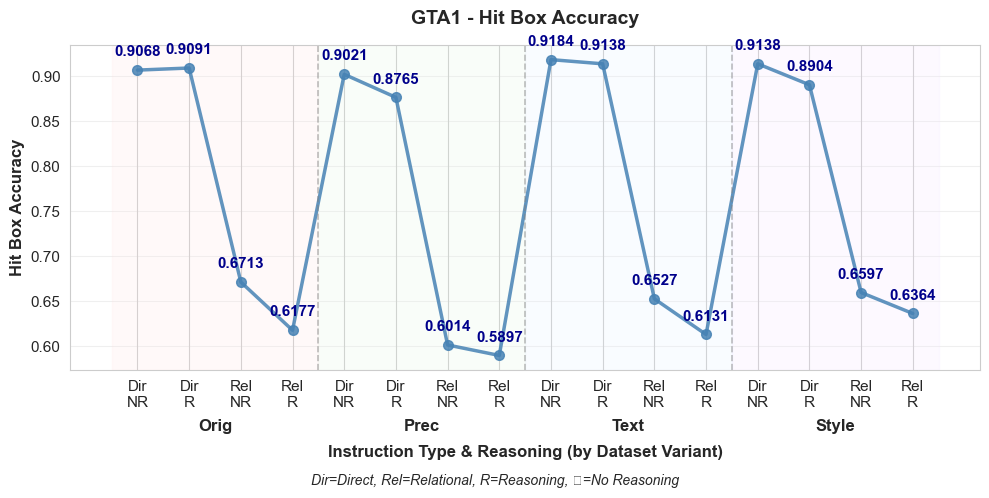

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


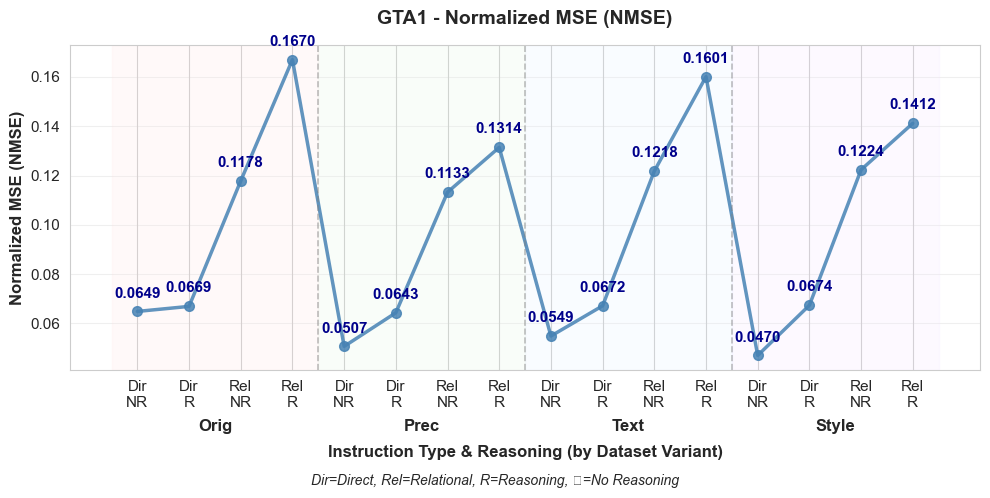

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


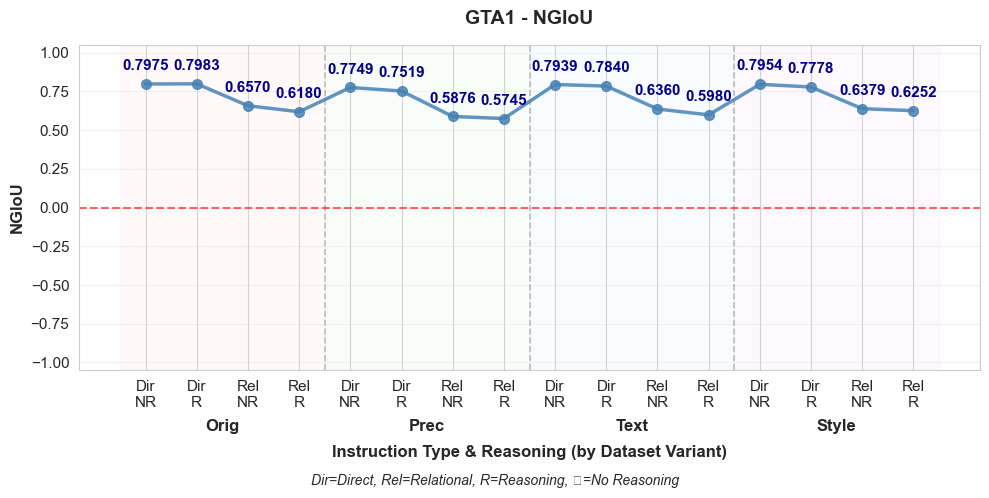

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


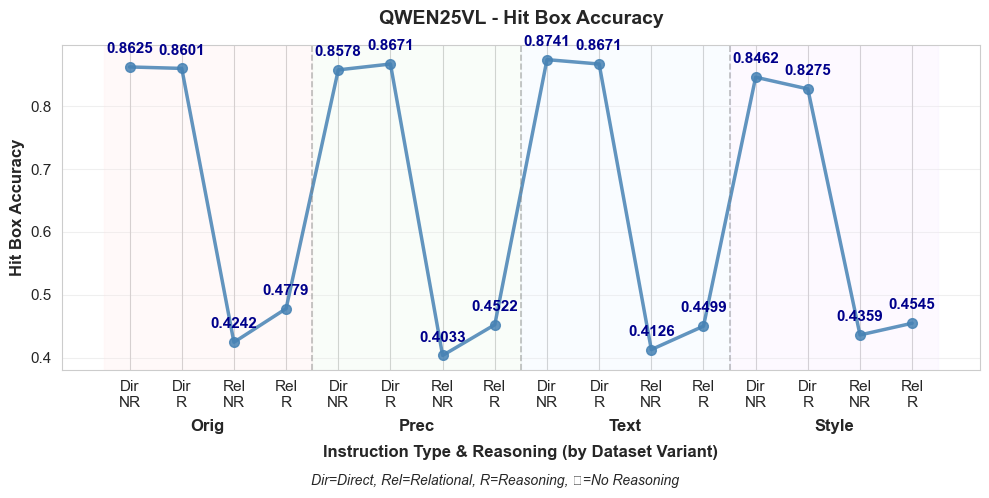

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


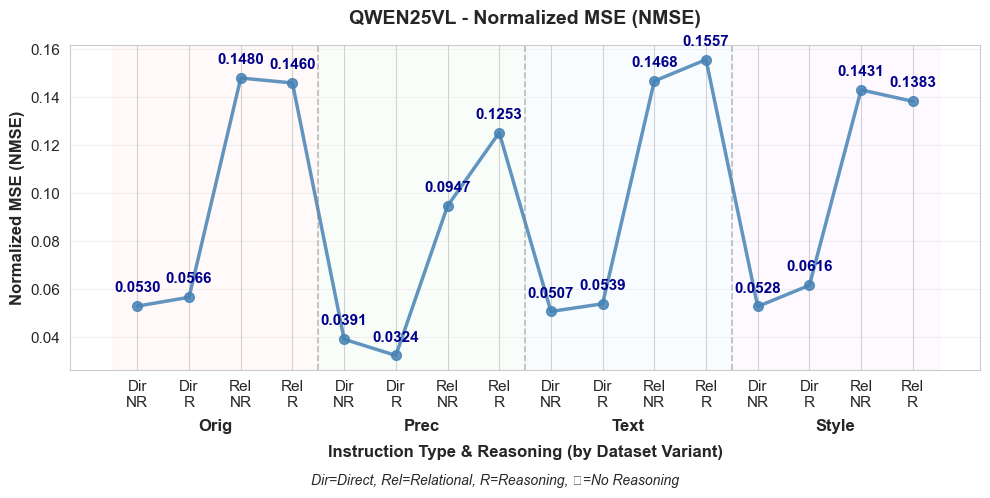

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


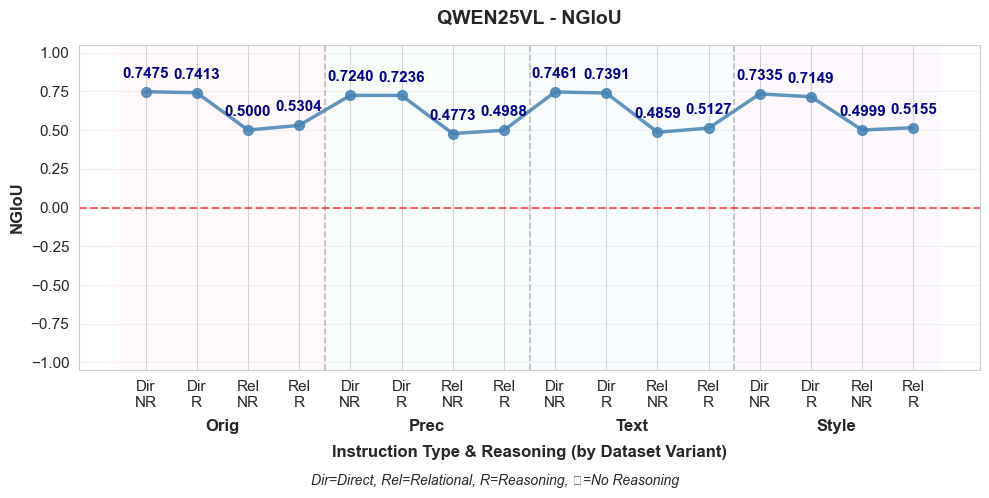

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


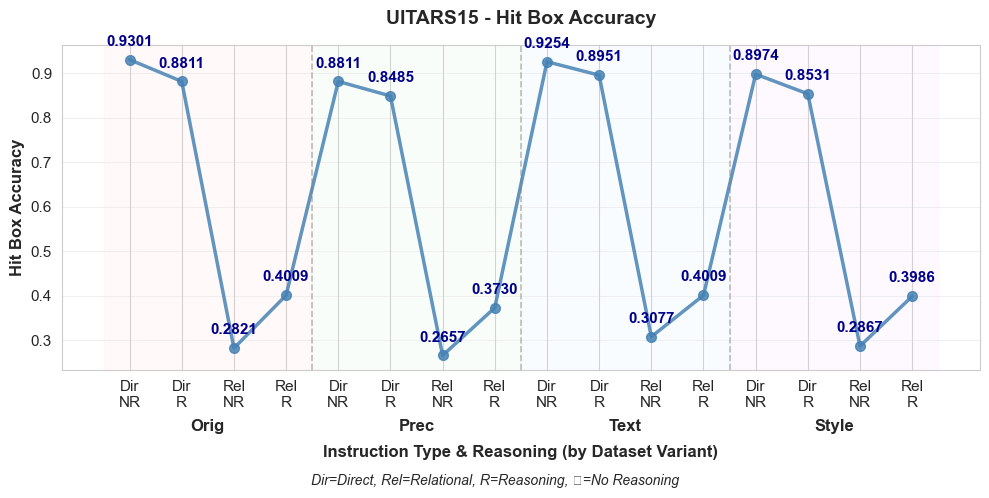

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


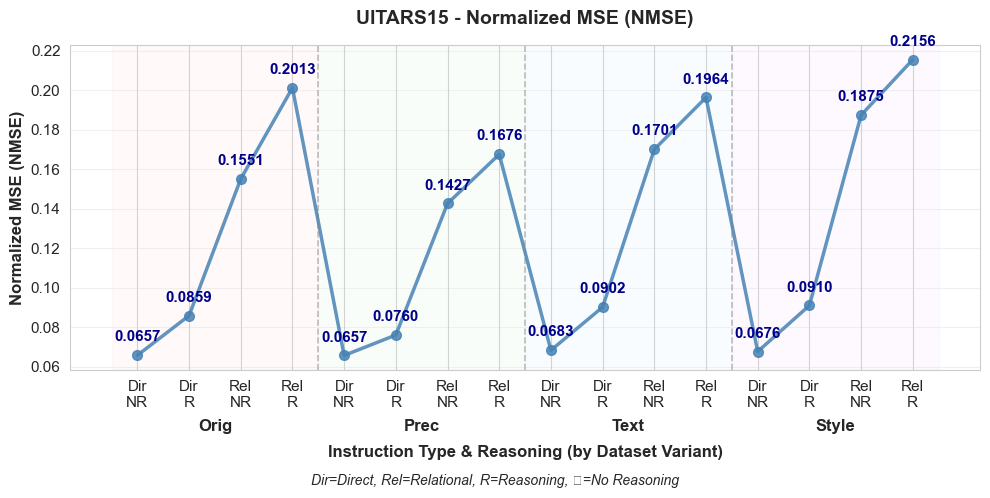

/Users/lockewang/FIG/WebDomainRandomizer/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


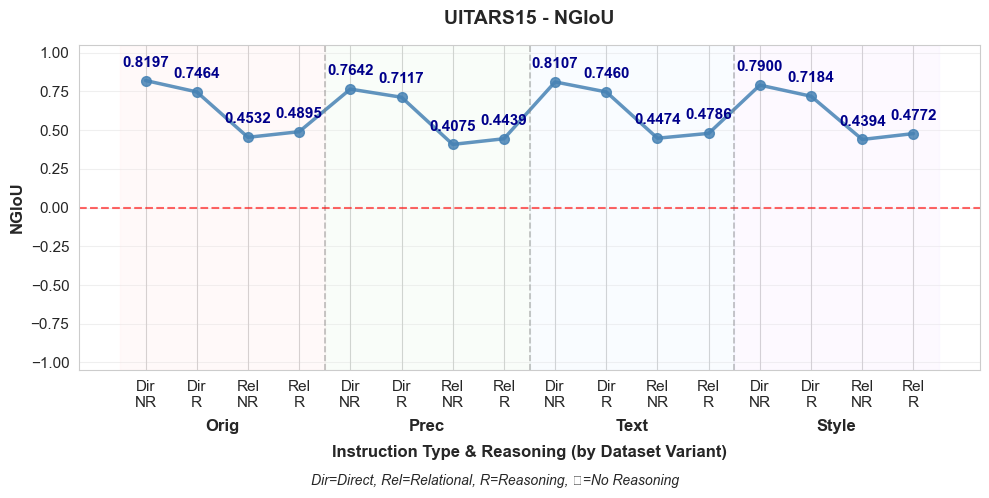

Configuration robustness plots completed!


In [163]:
# ============================================================================
# 6. CONFIGURATION ROBUSTNESS PLOTS
# ============================================================================

# Create a configuration label for each unique combination
df['config_label'] = df.apply(
    lambda row: f"{row['variant']}_{row['level']}_{'R' if row['use_reasoning'] else 'NR'}",
    axis=1
)

# Generate all possible configurations IN THE CORRECT ORDER
variants = ['original', 'precision', 'text_shrink', 'style']
levels = ['L1', 'L2']
reasoning_flags = [False, True]

all_configs = []
for variant in variants:
    for level in levels:
        for reasoning in reasoning_flags:
            config_label = f"{variant}_{level}_{'R' if reasoning else 'NR'}"
            all_configs.append((config_label, variant, level, reasoning))

config_order = [c[0] for c in all_configs]

# Mapping for cleaner labels
variant_map = {
    'original': 'Orig',
    'precision': 'Prec',
    'text_shrink': 'Text',
    'style': 'Style'
}
level_map = {
    'L1': 'Dir',
    'L2': 'Rel'
}

# Create one figure per model per metric (optimized for 2-column paper)
for model in model_order:
    for metric in ['hit_box_accuracy', 'normalized_mse', 'ngiou']:
        # Optimized for 2-column format: width ~3.5 inches, height appropriate for visibility
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        
        # Title with model and metric
        ax.set_title(f'{model.upper()} - {metric_labels.get(metric, metric)}', 
                    fontsize=14, fontweight='bold', pad=15)
        
        # Filter data for this model
        model_df = df[df['model'] == model]
        
        # Calculate mean for each configuration
        results = []
        for config_label in config_order:
            group = model_df[model_df['config_label'] == config_label]
            values = group[metric].dropna()
            if len(values) > 0:
                mean_val = np.nanmean(values)
                results.append({
                    'config_label': config_label,
                    'mean': mean_val,
                    'n': len(values)
                })
            else:
                results.append({
                    'config_label': config_label,
                    'mean': np.nan,
                    'n': 0
                })
        config_stats = pd.DataFrame(results)
        
        # Prepare data in config order
        x_pos = np.arange(len(config_order))
        y_vals = []
        
        for config_label in config_order:
            config_data = config_stats[config_stats['config_label'] == config_label]
            if len(config_data) > 0 and not np.isnan(config_data['mean'].values[0]):
                mean_val = config_data['mean'].values[0]
                y_vals.append(mean_val)
            else:
                y_vals.append(np.nan)
        
        # Plot line without error bars
        ax.plot(
            x_pos, y_vals,
            marker='o',
            color='steelblue',
            linewidth=2.5,
            markersize=7,
            alpha=0.85
        )
        
        # Add value labels - larger font
        for i, (x, y) in enumerate(zip(x_pos, y_vals)):
            if not np.isnan(y):
                ax.annotate(f'{y:.4f}',  # 2 decimals to save space
                           xy=(x, y), 
                           xytext=(0, 10), 
                           textcoords='offset points',
                           ha='center', 
                           fontsize=11,
                           fontweight='bold',
                           color='darkblue')
        
        # Add vertical separators between variants
        variant_colors = ['#FFE5E5', '#E5F5E5', '#E5F0FF', '#F5E5FF']  # Lighter shades
        for i in range(4, len(config_order), 4):
            ax.axvline(x=i-0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.5)
        
        # Add background shading for each variant group
        for i, variant in enumerate(variants):
            start_x = i * 4 - 0.5
            end_x = (i + 1) * 4 - 0.5
            ax.axvspan(start_x, end_x, alpha=0.2, color=variant_colors[i])
        
        # Create x-axis labels - simplified for readability
        x_labels = []
        for idx, (config_label, variant, level, reasoning) in enumerate(all_configs):
            variant_short = variant_map.get(variant, variant)
            level_short = level_map.get(level, level)
            reasoning_short = 'R' if reasoning else 'NR'  # Use symbol for compactness
            x_labels.append(f"{level_short}\n{reasoning_short}")
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=11)
        
        # Add variant labels below x-axis manually
        for i, variant in enumerate(variants):
            x_center = (i * 4) + 1.5
            ax.text(x_center, -0.15, variant_map[variant], 
                   ha='center', va='top', fontsize=12, fontweight='bold',
                   transform=ax.get_xaxis_transform())
        
        ax.set_xlabel('Instruction Type & Reasoning (by Dataset Variant)', 
                     fontsize=12, fontweight='bold', labelpad=25)
        ax.set_ylabel(metric_labels.get(metric, metric), 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y', linewidth=0.8)
        
        # Adjust y-axis
        ax.tick_params(axis='both', which='major', labelsize=11)
        
        # Set y-axis range for ngiou
        if metric == 'ngiou':
            ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax.set_ylim(-1.05, 1.05)
        
        # Compact legend at top
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#FFE5E5', alpha=0.5, label='Orig'),
            Patch(facecolor='#E5F5E5', alpha=0.5, label='Prec'),
            Patch(facecolor='#E5F0FF', alpha=0.5, label='Text'),
            Patch(facecolor='#F5E5FF', alpha=0.5, label='Style')
        ]
        
        # Compact note
        fig.text(0.5, 0.02, 
                 'Dir=Direct, Rel=Relational, R=Reasoning, ∅=No Reasoning',
                 ha='center', fontsize=10, style='italic')
        
        plt.tight_layout(rect=[0, 0.04, 1, 1])
        plt.show()

print("Configuration robustness plots completed!")

In [38]:
summary_df.groupby('variant').head()

,model,variant,use_reasoning,level,hit_box_accuracy,bbox_center_mse,normalized_mse,giou,ngiou,reasoning_label,model_label
0,gta1,original,False,L1,0.906760,20736.736898,0.064884,0.594961,0.797480,No Reasoning,GTA1
1,gta1,original,False,L2,0.671329,27650.713634,0.117846,0.314079,0.657039,No Reasoning,GTA1
2,gta1,original,True,L1,0.909091,24870.164992,0.066929,0.596579,0.798290,Reasoning,GTA1
3,gta1,original,True,L2,0.617716,45807.924732,0.167027,0.235905,0.617952,Reasoning,GTA1
4,gta1,precision,False,L1,0.902098,14403.016046,0.050700,0.549803,0.774902,No Reasoning,GTA1
5,gta1,precision,False,L2,0.601399,30924.480614,0.113252,0.175276,0.587638,No Reasoning,GTA1
6,gta1,precision,True,L1,0.876457,27334.284969,0.064350,0.503711,0.751856,Reasoning,GTA1
7,gta1,precision,True,L2,0.589744,39784.246322,0.131428,0.148950,0.574475,Reasoning,GTA1
8,gta1,style,False,L1,0.913753,9407.494109,0.047025,0.590702,0.795351,No Reasoning,GTA1
9,gta1,style,False,L2,0.659674,30804.854041,0.122359,0.275712,0.637856,No Reasoning,GTA1
